In [1]:
import pandas as pd
import duckdb
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import numpy as np
import sys

con = duckdb.connect()

# t13 데이터 하....결측 처리 완료

In [ ]:
# duckdb 컬럼 확인(일단 큰데이터순으로 t13, t25, t26, t27)
path = "../data/t13_2023_2025_all.parquet"
schema = con.execute(f"""
DESCRIBE SELECT * FROM read_parquet('{path}')
""").fetchdf()
schema

,column_name,column_type,null,key,default,extra
0,ETL_YMD,VARCHAR,YES,None,None,None
1,O_ADMI_CD,VARCHAR,YES,None,None,None
2,O_MEGA_NM,VARCHAR,YES,None,None,None
3,O_CTY_NM,VARCHAR,YES,None,None,None
4,O_ADMI_NM,VARCHAR,YES,None,None,None
5,O_CENTER_X,DOUBLE,YES,None,None,None
6,O_CENTER_Y,DOUBLE,YES,None,None,None
7,D_ADMI_CD,VARCHAR,YES,None,None,None
8,D_MEGA_NM,VARCHAR,YES,None,None,None
9,D_CTY_NM,VARCHAR,YES,None,None,None


- t13 데이터는 출발/도착/목적/성별/연령대별 등 이동 집계 데이터로 확인
- ETL_YMD = 특정날짜
  출발 행정동/도착 행정동(예: O_ADMI_CD, O_ADMI_NM, D_ADMI_CD, D_ADMI_NM)
- PURPOSE = 목적
- SEX_CD = 성별
- AGE_GRP	= 연령대
- CNT	= 이동량 및 집계값들

일단 날짜데이터부터 확인.

In [107]:
con.execute("""
select
    min(ETL_YMD) AS min_date,
    max(ETL_YMD) AS max_date,
    count(*) AS row_cnt,
    count(ETL_YMD) AS non_null_date
from read_parquet('../data/t13_2023_2025_all.parquet')
""").fetchdf()

,min_date,max_date,row_cnt,non_null_date
0,20230101,20251231,279996851,279996851


날짜는 정삭정으로 확인 date형태로만 바꿔주면 됨, 전체행은 약2억8천행 모든행에 다 값이 들어있음.

In [ ]:
# 날짜부터 변환
con.execute("""
COPY (
    SELECT
        CAST(STRPTIME(ETL_YMD, '%Y%m%d') AS DATE) AS ETL_YMD,
        *
    EXCLUDE (ETL_YMD)
    FROM read_parquet('../data/t13_2023_2025_all.parquet')
)
TO '../data/t13_2023_2025_all_clean.parquet' (FORMAT PARQUET);
""")

In [ ]:
# date변환 후 행 확인
print(con.execute("""
SELECT COUNT(*) FROM read_parquet('../data/t13_2023_2025_all.parquet')
""").fetchdf())

print(con.execute("""
SELECT COUNT(*) FROM read_parquet('../data/t13_2023_2025_all_clean.parquet')
""").fetchdf())

   count_star()
0     279996851
   count_star()
0     279996851


In [ ]:
# 타입 확인
con.execute("""
describe select *
from read_parquet('../data/t13_2023_2025_all_clean.parquet')""").fetchdf()

,column_name,column_type,null,key,default,extra
0,ETL_YMD,DATE,YES,None,None,None
1,O_ADMI_CD,VARCHAR,YES,None,None,None
2,O_MEGA_NM,VARCHAR,YES,None,None,None
3,O_CTY_NM,VARCHAR,YES,None,None,None
4,O_ADMI_NM,VARCHAR,YES,None,None,None
5,O_CENTER_X,DOUBLE,YES,None,None,None
6,O_CENTER_Y,DOUBLE,YES,None,None,None
7,D_ADMI_CD,VARCHAR,YES,None,None,None
8,D_MEGA_NM,VARCHAR,YES,None,None,None
9,D_CTY_NM,VARCHAR,YES,None,None,None


In [ ]:
con.execute("""
select etl_ymd
from read_parquet('../data/t13_2023_2025_all_clean.parquet')
limit 10""").fetchdf()

,ETL_YMD
0,2023-01-29
1,2023-01-24
2,2023-01-19
3,2023-01-31
4,2023-01-02
5,2023-01-31
6,2023-01-30
7,2023-01-04
8,2023-01-01
9,2023-01-30


날짜변환 완료!

이제 모든컬럼 결측여부 확인.

## t13 결측 처리

In [ ]:
con.execute("""
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN ETL_YMD IS NULL THEN 1 ELSE 0 END) AS etl_ymd_null,
    SUM(CASE WHEN O_ADMI_CD IS NULL THEN 1 ELSE 0 END) AS o_admi_cd_null,
    SUM(CASE WHEN O_MEGA_NM IS NULL THEN 1 ELSE 0 END) AS o_mega_nm_null,
    SUM(CASE WHEN O_CTY_NM IS NULL THEN 1 ELSE 0 END) AS o_cty_nm_null,
    SUM(CASE WHEN O_ADMI_NM IS NULL THEN 1 ELSE 0 END) AS o_admi_nm_null,
    SUM(CASE WHEN O_CENTER_X IS NULL THEN 1 ELSE 0 END) AS o_x_null,
    SUM(CASE WHEN O_CENTER_Y IS NULL THEN 1 ELSE 0 END) AS o_y_null,
    SUM(CASE WHEN D_ADMI_CD IS NULL THEN 1 ELSE 0 END) AS d_admi_cd_null,
    SUM(CASE WHEN D_MEGA_NM IS NULL THEN 1 ELSE 0 END) AS d_mega_nm_null,
    SUM(CASE WHEN D_CTY_NM IS NULL THEN 1 ELSE 0 END) AS d_cty_nm_null,
    SUM(CASE WHEN D_ADMI_NM IS NULL THEN 1 ELSE 0 END) AS d_admi_nm_null,
    SUM(CASE WHEN D_CENTER_X IS NULL THEN 1 ELSE 0 END) AS d_x_null,
    SUM(CASE WHEN D_CENTER_Y IS NULL THEN 1 ELSE 0 END) AS d_y_null,
    SUM(CASE WHEN PURPOSE IS NULL THEN 1 ELSE 0 END) AS purpose_null,
    SUM(CASE WHEN SEX_CD IS NULL THEN 1 ELSE 0 END) AS sex_null,
    SUM(CASE WHEN AGE_GRP IS NULL THEN 1 ELSE 0 END) AS age_null,
    SUM(CASE WHEN CNT IS NULL THEN 1 ELSE 0 END) AS cnt_null
FROM read_parquet('../data/t13_2023_2025_all_clean.parquet')
""").fetchdf()

,total_rows,etl_ymd_null,o_admi_cd_null,o_mega_nm_null,o_cty_nm_null,o_admi_nm_null,o_x_null,o_y_null,d_admi_cd_null,d_mega_nm_null,d_cty_nm_null,d_admi_nm_null,d_x_null,d_y_null,purpose_null,sex_null,age_null,cnt_null
0,279996851,0.0,0.0,9112.0,116454.0,9112.0,9112.0,9112.0,0.0,9055.0,114893.0,9055.0,9055.0,9055.0,0.0,0.0,0.0,0.0


In [7]:
con.execute("""
SELECT *
FROM read_parquet('../data/t13_2023_2025_all_clean.parquet')
WHERE O_CTY_NM IS NULL 
""").fetchdf()

,ETL_YMD,O_ADMI_CD,O_MEGA_NM,O_CTY_NM,O_ADMI_NM,O_CENTER_X,O_CENTER_Y,D_ADMI_CD,D_MEGA_NM,D_CTY_NM,D_ADMI_NM,D_CENTER_X,D_CENTER_Y,PURPOSE,SEX_CD,AGE_GRP,CNT
0,2023-01-14,36110510,세종특별자치시,None,한솔동,977564.0,1830664.0,41135670,경기도,성남시 분당구,구미동,966450.0,1927124.0,6,M,5,2.79
1,2023-01-13,36110515,세종특별자치시,None,새롬동,980641.0,1833717.0,41135580,경기도,성남시 분당구,서현1동,968958.0,1931893.0,6,M,5,3.83
2,2023-01-01,36110515,세종특별자치시,None,새롬동,980641.0,1833717.0,41131625,경기도,성남시 수정구,위례동,968771.0,1941010.0,6,W,5,3.15
3,2023-01-09,36110530,세종특별자치시,None,아름동,977573.0,1835572.0,41135655,경기도,성남시 분당구,삼평동,965321.0,1933724.0,6,M,5,4.35
4,2023-01-23,36110510,세종특별자치시,None,한솔동,977564.0,1830664.0,41133510,경기도,성남시 중원구,성남동,967502.0,1936961.0,6,M,6,2.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116449,2025-12-31,36110580,세종특별자치시,None,다정동,977165.0,1833026.0,41131640,경기도,성남시 수정구,고등동,962931.0,1936753.0,1,M,5,3.26
116450,2025-12-31,36110580,세종특별자치시,None,다정동,977165.0,1833026.0,41135620,경기도,성남시 분당구,야탑1동,966889.0,1934945.0,0,M,6,3.09
116451,2025-12-31,36110580,세종특별자치시,None,다정동,977165.0,1833026.0,41135620,경기도,성남시 분당구,야탑1동,966889.0,1934945.0,6,F,5,3.50
116452,2025-12-31,36110580,세종특별자치시,None,다정동,977165.0,1833026.0,41135630,경기도,성남시 분당구,야탑2동,966996.0,1934337.0,6,M,5,3.26


In [27]:
con.execute("""
SELECT *
FROM read_parquet('../data/t13_2023_2025_all_clean.parquet')
WHERE O_MEGA_NM IS NULL 
    AND O_CTY_NM IS NULL 
    AND O_ADMI_NM IS NULL
""").fetchdf()

,ETL_YMD,O_ADMI_CD,O_MEGA_NM,O_CTY_NM,O_ADMI_NM,O_CENTER_X,O_CENTER_Y,D_ADMI_CD,D_MEGA_NM,D_CTY_NM,D_ADMI_NM,D_CENTER_X,D_CENTER_Y,PURPOSE,SEX_CD,AGE_GRP,CNT
0,2024-05-06,99,None,None,None,NaN,NaN,41135662,경기도,성남시 분당구,금곡동,964227.0,1929414.0,6,M,5,3.33
1,2024-05-21,99,None,None,None,NaN,NaN,41131640,경기도,성남시 수정구,고등동,962931.0,1936753.0,0,M,4,2.84
2,2024-05-21,99,None,None,None,NaN,NaN,41131640,경기도,성남시 수정구,고등동,962931.0,1936753.0,0,W,4,2.63
3,2024-05-18,99,None,None,None,NaN,NaN,41133510,경기도,성남시 중원구,성남동,967502.0,1936961.0,0,W,4,3.73
4,2024-05-06,99,None,None,None,NaN,NaN,41135662,경기도,성남시 분당구,금곡동,964227.0,1929414.0,6,M,3,3.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9107,2025-09-30,11230533,None,None,None,NaN,NaN,41135662,경기도,성남시 분당구,금곡동,964227.0,1929414.0,2,M,4,3.99
9108,2025-09-30,11230533,None,None,None,NaN,NaN,41135662,경기도,성남시 분당구,금곡동,964227.0,1929414.0,6,F,6,3.83
9109,2025-09-30,11230533,None,None,None,NaN,NaN,41135670,경기도,성남시 분당구,구미동,966450.0,1927124.0,0,M,5,2.43
9110,2025-09-30,11230533,None,None,None,NaN,NaN,41135670,경기도,성남시 분당구,구미동,966450.0,1927124.0,6,M,4,3.99


결측 확인
- O_MEGA_NM: 9,112(출발 광역시도명)
- O_CTY_NM: 116,454(출발 시군구명)
- O_ADMI_NM: 9,112(출발 행정동명)
- O_CENTER_X/Y: 9,112(출발 좌표)
- D_MEGA_NM: 9,055(도착 광역시도명)
- D_CTY_NM: 114,893(도착 시군구명)
- D_ADMI_NM: 9,055(도착 행정동명)
- D_CENTER_X/Y: 9,055(도착 좌표)

## t13 데이터 결론
- 전체 행: 279,996,851
- 날짜, 코드, CNT, 성별, 연령, 목적 -> 결측 0
- 행정명/좌표 컬럼에만 결측 존재

# t13-1 결측 처리 방법

In [5]:
con.execute("""
COPY (
    SELECT
        ETL_YMD,
        O_ADMI_CD,

        MAX(O_MEGA_NM) OVER (PARTITION BY O_ADMI_CD) AS O_MEGA_NM,
        MAX(O_CTY_NM)  OVER (PARTITION BY O_ADMI_CD) AS O_CTY_NM,
        MAX(O_ADMI_NM) OVER (PARTITION BY O_ADMI_CD) AS O_ADMI_NM,

        MAX(O_CENTER_X) OVER (PARTITION BY O_ADMI_CD) AS O_CENTER_X,
        MAX(O_CENTER_Y) OVER (PARTITION BY O_ADMI_CD) AS O_CENTER_Y,

        D_ADMI_CD,
        D_MEGA_NM,
        D_CTY_NM,
        D_ADMI_NM,
        D_CENTER_X,
        D_CENTER_Y,
        PURPOSE,
        SEX_CD,
        AGE_GRP,
        CNT
    FROM read_parquet('../data/t13_2023_2025_all_clean.parquet')
)
TO '../data/t13_2023_2025_all_clean_fixed.parquet'
(FORMAT PARQUET);
""")

In [7]:
con.execute("""
SELECT *
FROM read_parquet('../data/t13_2023_2025_all_clean_fixed.parquet')
WHERE O_ADMI_CD = 11230533
""").fetchdf()

,ETL_YMD,O_ADMI_CD,O_MEGA_NM,O_CTY_NM,O_ADMI_NM,O_CENTER_X,O_CENTER_Y,D_ADMI_CD,D_MEGA_NM,D_CTY_NM,D_ADMI_NM,D_CENTER_X,D_CENTER_Y,PURPOSE,SEX_CD,AGE_GRP,CNT
0,2025-08-01,11230533,서울특별시,동대문구,용두동,959136.0,1953064.0,41131520,경기도,성남시 수정구,신흥2동,968874.0,1938983.0,0,F,6,2.90
1,2025-08-01,11230533,서울특별시,동대문구,용두동,959136.0,1953064.0,41131530,경기도,성남시 수정구,신흥3동,968741.0,1938245.0,6,M,6,3.50
2,2025-08-01,11230533,서울특별시,동대문구,용두동,959136.0,1953064.0,41131550,경기도,성남시 수정구,태평2동,967839.0,1938789.0,0,M,3,2.91
3,2025-08-01,11230533,서울특별시,동대문구,용두동,959136.0,1953064.0,41131561,경기도,성남시 수정구,태평4동,968237.0,1938859.0,0,F,3,2.83
4,2025-08-01,11230533,서울특별시,동대문구,용두동,959136.0,1953064.0,41131580,경기도,성남시 수정구,수진2동,966922.0,1937543.0,0,M,8,3.63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9934,2025-12-31,11230533,서울특별시,동대문구,용두동,959136.0,1953064.0,41135665,경기도,성남시 분당구,구미1동,964009.0,1928230.0,0,M,8,2.63
9935,2025-12-31,11230533,서울특별시,동대문구,용두동,959136.0,1953064.0,41135670,경기도,성남시 분당구,구미동,966450.0,1927124.0,1,F,6,3.87
9936,2025-12-31,11230533,서울특별시,동대문구,용두동,959136.0,1953064.0,41135670,경기도,성남시 분당구,구미동,966450.0,1927124.0,1,M,6,3.85
9937,2025-12-31,11230533,서울특별시,동대문구,용두동,959136.0,1953064.0,41135680,경기도,성남시 분당구,운중동,960911.0,1931508.0,0,F,6,2.72


In [8]:
con.execute("""
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN ETL_YMD IS NULL THEN 1 ELSE 0 END) AS etl_ymd_null,
    SUM(CASE WHEN O_ADMI_CD IS NULL THEN 1 ELSE 0 END) AS o_admi_cd_null,
    SUM(CASE WHEN O_MEGA_NM IS NULL THEN 1 ELSE 0 END) AS o_mega_nm_null,
    SUM(CASE WHEN O_CTY_NM IS NULL THEN 1 ELSE 0 END) AS o_cty_nm_null,
    SUM(CASE WHEN O_ADMI_NM IS NULL THEN 1 ELSE 0 END) AS o_admi_nm_null,
    SUM(CASE WHEN O_CENTER_X IS NULL THEN 1 ELSE 0 END) AS o_x_null,
    SUM(CASE WHEN O_CENTER_Y IS NULL THEN 1 ELSE 0 END) AS o_y_null,
    SUM(CASE WHEN D_ADMI_CD IS NULL THEN 1 ELSE 0 END) AS d_admi_cd_null,
    SUM(CASE WHEN D_MEGA_NM IS NULL THEN 1 ELSE 0 END) AS d_mega_nm_null,
    SUM(CASE WHEN D_CTY_NM IS NULL THEN 1 ELSE 0 END) AS d_cty_nm_null,
    SUM(CASE WHEN D_ADMI_NM IS NULL THEN 1 ELSE 0 END) AS d_admi_nm_null,
    SUM(CASE WHEN D_CENTER_X IS NULL THEN 1 ELSE 0 END) AS d_x_null,
    SUM(CASE WHEN D_CENTER_Y IS NULL THEN 1 ELSE 0 END) AS d_y_null,
    SUM(CASE WHEN PURPOSE IS NULL THEN 1 ELSE 0 END) AS purpose_null,
    SUM(CASE WHEN SEX_CD IS NULL THEN 1 ELSE 0 END) AS sex_null,
    SUM(CASE WHEN AGE_GRP IS NULL THEN 1 ELSE 0 END) AS age_null,
    SUM(CASE WHEN CNT IS NULL THEN 1 ELSE 0 END) AS cnt_null
FROM read_parquet('../data/t13_2023_2025_all_clean_fixed.parquet')
""").fetchdf()

,total_rows,etl_ymd_null,o_admi_cd_null,o_mega_nm_null,o_cty_nm_null,o_admi_nm_null,o_x_null,o_y_null,d_admi_cd_null,d_mega_nm_null,d_cty_nm_null,d_admi_nm_null,d_x_null,d_y_null,purpose_null,sex_null,age_null,cnt_null
0,279996851,0.0,0.0,8.0,107350.0,8.0,8.0,8.0,0.0,9055.0,114893.0,9055.0,9055.0,9055.0,0.0,0.0,0.0,0.0


11230533은 코드 확인후 코드랑 같은 지역으로 결측값 정리 완료 나머지 99코드는 데이터 제공측 자체에서 미확인을 표시하기 위해 99라고 둔걸로 설명해줘 그대로 두기로 결정 이제 세종특별시의 시군구만 none값을 unknown으로 대체하면 됨

In [9]:
con.execute("""
SELECT *
FROM read_parquet('../data/t13_2023_2025_all_clean_fixed.parquet')
WHERE O_MEGA_NM IS NULL 
    AND O_CTY_NM IS NULL 
    AND O_ADMI_NM IS NULL
""").fetchdf()

,ETL_YMD,O_ADMI_CD,O_MEGA_NM,O_CTY_NM,O_ADMI_NM,O_CENTER_X,O_CENTER_Y,D_ADMI_CD,D_MEGA_NM,D_CTY_NM,D_ADMI_NM,D_CENTER_X,D_CENTER_Y,PURPOSE,SEX_CD,AGE_GRP,CNT
0,2024-05-06,99,None,None,None,NaN,NaN,41135662,경기도,성남시 분당구,금곡동,964227.0,1929414.0,6,M,5,3.33
1,2024-05-21,99,None,None,None,NaN,NaN,41131640,경기도,성남시 수정구,고등동,962931.0,1936753.0,0,M,4,2.84
2,2024-05-21,99,None,None,None,NaN,NaN,41131640,경기도,성남시 수정구,고등동,962931.0,1936753.0,0,W,4,2.63
3,2024-05-18,99,None,None,None,NaN,NaN,41133510,경기도,성남시 중원구,성남동,967502.0,1936961.0,0,W,4,3.73
4,2024-05-06,99,None,None,None,NaN,NaN,41135662,경기도,성남시 분당구,금곡동,964227.0,1929414.0,6,M,3,3.67
5,2024-05-18,99,None,None,None,NaN,NaN,41133510,경기도,성남시 중원구,성남동,967502.0,1936961.0,0,M,4,2.55
6,2024-05-19,99,None,None,None,NaN,NaN,41135510,경기도,성남시 분당구,분당동,968513.0,1930041.0,1,W,6,3.62
7,2024-05-19,99,None,None,None,NaN,NaN,41135510,경기도,성남시 분당구,분당동,968513.0,1930041.0,1,M,6,2.96


In [10]:
con.execute("""
COPY (
    SELECT
        * EXCLUDE (O_CTY_NM),

        CASE
            WHEN O_MEGA_NM = '세종특별자치시' AND O_CTY_NM IS NULL
                THEN 'UNKNOWN'
            ELSE O_CTY_NM
        END AS O_CTY_NM

    FROM read_parquet('../data/t13_2023_2025_all_clean_fixed.parquet')
)
TO '../data/t13_2023_2025_all_final.parquet'
(FORMAT PARQUET);
""")

In [11]:
con.execute("""
SELECT *
FROM read_parquet('../data/t13_2023_2025_all_final.parquet')
WHERE O_CTY_NM IS NULL 
""").fetchdf()

,ETL_YMD,O_ADMI_CD,O_MEGA_NM,O_ADMI_NM,O_CENTER_X,O_CENTER_Y,D_ADMI_CD,D_MEGA_NM,D_CTY_NM,D_ADMI_NM,D_CENTER_X,D_CENTER_Y,PURPOSE,SEX_CD,AGE_GRP,CNT,O_CTY_NM
0,2024-05-06,99,None,None,NaN,NaN,41135662,경기도,성남시 분당구,금곡동,964227.0,1929414.0,6,M,5,3.33,None
1,2024-05-21,99,None,None,NaN,NaN,41131640,경기도,성남시 수정구,고등동,962931.0,1936753.0,0,M,4,2.84,None
2,2024-05-21,99,None,None,NaN,NaN,41131640,경기도,성남시 수정구,고등동,962931.0,1936753.0,0,W,4,2.63,None
3,2024-05-18,99,None,None,NaN,NaN,41133510,경기도,성남시 중원구,성남동,967502.0,1936961.0,0,W,4,3.73,None
4,2024-05-06,99,None,None,NaN,NaN,41135662,경기도,성남시 분당구,금곡동,964227.0,1929414.0,6,M,3,3.67,None
5,2024-05-18,99,None,None,NaN,NaN,41133510,경기도,성남시 중원구,성남동,967502.0,1936961.0,0,M,4,2.55,None
6,2024-05-19,99,None,None,NaN,NaN,41135510,경기도,성남시 분당구,분당동,968513.0,1930041.0,1,W,6,3.62,None
7,2024-05-19,99,None,None,NaN,NaN,41135510,경기도,성남시 분당구,분당동,968513.0,1930041.0,1,M,6,2.96,None


In [12]:
con.execute("""
SELECT
    O_MEGA_NM,
    O_CTY_NM,
    COUNT(*) AS cnt
FROM read_parquet('../data/t13_2023_2025_all_final.parquet')
WHERE O_MEGA_NM = '세종특별자치시'
GROUP BY 1,2;
""").fetchdf()

,O_MEGA_NM,O_CTY_NM,cnt
0,세종특별자치시,UNKNOWN,107342


In [14]:
con.execute("""
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN ETL_YMD IS NULL THEN 1 ELSE 0 END) AS etl_ymd_null,
    SUM(CASE WHEN O_ADMI_CD IS NULL THEN 1 ELSE 0 END) AS o_admi_cd_null,
    SUM(CASE WHEN O_MEGA_NM IS NULL THEN 1 ELSE 0 END) AS o_mega_nm_null,
    SUM(CASE WHEN O_CTY_NM IS NULL THEN 1 ELSE 0 END) AS o_cty_nm_null,
    SUM(CASE WHEN O_ADMI_NM IS NULL THEN 1 ELSE 0 END) AS o_admi_nm_null,
    SUM(CASE WHEN O_CENTER_X IS NULL THEN 1 ELSE 0 END) AS o_x_null,
    SUM(CASE WHEN O_CENTER_Y IS NULL THEN 1 ELSE 0 END) AS o_y_null,
    SUM(CASE WHEN D_ADMI_CD IS NULL THEN 1 ELSE 0 END) AS d_admi_cd_null,
    SUM(CASE WHEN D_MEGA_NM IS NULL THEN 1 ELSE 0 END) AS d_mega_nm_null,
    SUM(CASE WHEN D_CTY_NM IS NULL THEN 1 ELSE 0 END) AS d_cty_nm_null,
    SUM(CASE WHEN D_ADMI_NM IS NULL THEN 1 ELSE 0 END) AS d_admi_nm_null,
    SUM(CASE WHEN D_CENTER_X IS NULL THEN 1 ELSE 0 END) AS d_x_null,
    SUM(CASE WHEN D_CENTER_Y IS NULL THEN 1 ELSE 0 END) AS d_y_null,
    SUM(CASE WHEN PURPOSE IS NULL THEN 1 ELSE 0 END) AS purpose_null,
    SUM(CASE WHEN SEX_CD IS NULL THEN 1 ELSE 0 END) AS sex_null,
    SUM(CASE WHEN AGE_GRP IS NULL THEN 1 ELSE 0 END) AS age_null,
    SUM(CASE WHEN CNT IS NULL THEN 1 ELSE 0 END) AS cnt_null
FROM read_parquet('../data/t13_2023_2025_all_final.parquet')
""").fetchdf()

,total_rows,etl_ymd_null,o_admi_cd_null,o_mega_nm_null,o_cty_nm_null,o_admi_nm_null,o_x_null,o_y_null,d_admi_cd_null,d_mega_nm_null,d_cty_nm_null,d_admi_nm_null,d_x_null,d_y_null,purpose_null,sex_null,age_null,cnt_null
0,279996851,0.0,0.0,8.0,8.0,8.0,8.0,8.0,0.0,9055.0,114893.0,9055.0,9055.0,9055.0,0.0,0.0,0.0,0.0


In [15]:
con.execute("""
SELECT
    O_ADMI_CD,
    O_MEGA_NM,
    O_CTY_NM,
    O_ADMI_NM,
    O_CENTER_X,
    O_CENTER_Y,
    COUNT(*) AS cnt
FROM read_parquet('../data/t13_2023_2025_all_final.parquet')
WHERE O_MEGA_NM IS NULL
   OR O_CTY_NM IS NULL
   OR O_ADMI_NM IS NULL
   OR O_CENTER_X IS NULL
   OR O_CENTER_Y IS NULL
GROUP BY 1,2,3,4,5,6
ORDER BY cnt DESC;
""").fetchdf()

,O_ADMI_CD,O_MEGA_NM,O_CTY_NM,O_ADMI_NM,O_CENTER_X,O_CENTER_Y,cnt
0,99,None,None,None,NaN,NaN,8


In [18]:
con.execute("""
SELECT
    O_ADMI_CD,
    COUNT(*) AS cnt
FROM read_parquet('../data/t13_2023_2025_all_final.parquet')
WHERE O_MEGA_NM IS NULL
   OR O_CTY_NM IS NULL
   OR O_ADMI_NM IS NULL
   OR O_CENTER_X IS NULL
   OR O_CENTER_Y IS NULL
GROUP BY 1
ORDER BY cnt DESC;
""").fetchdf()

,O_ADMI_CD,cnt
0,99,8


1. 세종특별자치시 시군구 결측 처리
세종특별자치시는 시군구 컬럼이 None으로 존재
행정구조상 시군구가 없는 케이스로 판단
O_CTY_NM의 None 값을 UNKNOWN으로 대체
2. 1123으로 시작하는 출발지 코드 결측 보정
일부 O_ADMI_CD가 1123으로 시작하는 데이터에서 지역명/좌표가 None으로 확인됨
동일 코드의 정상 매핑값을 확인한 뒤,
코드와 일치하는 지역명 및 좌표값으로 대체 완료
3. 99 코드 유지
O_ADMI_CD = 99는 총 8건 확인
데이터 공급처에서 미확인 지역을 표시하기 위해 99로 제공한 코드로 판단
임의 보정하지 않고 원본 의미를 유지하기로 결정

출발지 기준 결측은 구조적 결측과 매핑 누락을 보정했으며,
미확인 코드인 99는 원본 의미 보존을 위해 유지했다.
최종 분석용 파일은 t13_2023_2025_all_final.parquet로 확정한다.(도착도 똑같이 할 예정)

In [29]:
con.execute("""
SELECT *
FROM read_parquet('../data/t13_2023_2025_all_clean.parquet')
WHERE D_MEGA_NM IS NULL 
    AND D_CTY_NM IS NULL 
    AND D_ADMI_NM IS NULL
""").fetchdf()

,ETL_YMD,O_ADMI_CD,O_MEGA_NM,O_CTY_NM,O_ADMI_NM,O_CENTER_X,O_CENTER_Y,D_ADMI_CD,D_MEGA_NM,D_CTY_NM,D_ADMI_NM,D_CENTER_X,D_CENTER_Y,PURPOSE,SEX_CD,AGE_GRP,CNT
0,2024-05-18,41131640,경기도,성남시 수정구,고등동,962931.0,1936753.0,99,None,None,None,NaN,NaN,6,W,4,2.63
1,2024-05-18,41135520,경기도,성남시 분당구,수내1동,966002.0,1931166.0,99,None,None,None,NaN,NaN,0,W,7,3.50
2,2024-05-04,41135580,경기도,성남시 분당구,서현1동,968958.0,1931893.0,99,None,None,None,NaN,NaN,0,W,7,3.50
3,2024-05-31,41135655,경기도,성남시 분당구,삼평동,965321.0,1933724.0,99,None,None,None,NaN,NaN,6,M,5,1.94
4,2024-05-31,41135655,경기도,성남시 분당구,삼평동,965321.0,1933724.0,99,None,None,None,NaN,NaN,6,M,7,3.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9050,2025-09-30,41135680,경기도,성남시 분당구,운중동,960911.0,1931508.0,11230515,None,None,None,NaN,NaN,0,M,5,2.91
9051,2025-09-30,41135680,경기도,성남시 분당구,운중동,960911.0,1931508.0,11230515,None,None,None,NaN,NaN,0,M,7,2.51
9052,2025-09-30,41135680,경기도,성남시 분당구,운중동,960911.0,1931508.0,11230515,None,None,None,NaN,NaN,1,F,3,3.00
9053,2025-09-30,41135680,경기도,성남시 분당구,운중동,960911.0,1931508.0,11230533,None,None,None,NaN,NaN,0,F,6,4.09


도착 전체가 비는 행 수: 9055

도착 부분은 코드가 있는데 none처리된게 여러개인거 같아 확인부터하고 결측처리

In [16]:
con.execute("""
SELECT
    D_ADMI_CD,
    COUNT(*) AS cnt
FROM read_parquet('../data/t13_2023_2025_all_final.parquet')
WHERE D_MEGA_NM IS NULL
   OR D_CTY_NM IS NULL
   OR D_ADMI_NM IS NULL
   OR D_CENTER_X IS NULL
   OR D_CENTER_Y IS NULL
GROUP BY 1
ORDER BY cnt DESC;
""").fetchdf()

,D_ADMI_CD,cnt
0,36110523,15959
1,36110250,11268
2,36110520,7338
3,36110518,6565
4,36110550,6423
5,36110556,5741
6,36110530,4899
7,11230515,4678
8,36110370,4631
9,36110515,4476


시군구 코드별 여러코드에서 매핑이 빠진걸로 보인 99는 13개로 그대로 두고 나머지를 통일된 코드중 정보가 나와있는거 확인 후 결측 값을 대체 해야 할거 같음.

In [19]:
con.execute("""
SELECT
    D_ADMI_CD,
    COUNT(*) AS total_cnt,
    COUNT(D_MEGA_NM) AS mega_cnt,
    COUNT(D_CTY_NM) AS cty_cnt,
    COUNT(D_ADMI_NM) AS admi_cnt,
    COUNT(D_CENTER_X) AS x_cnt,
    COUNT(D_CENTER_Y) AS y_cnt,

    MAX(D_MEGA_NM) AS sample_mega_nm,
    MAX(D_CTY_NM) AS sample_cty_nm,
    MAX(D_ADMI_NM) AS sample_admi_nm,
    MAX(D_CENTER_X) AS sample_x,
    MAX(D_CENTER_Y) AS sample_y

FROM read_parquet('../data/t13_2023_2025_all_final.parquet')
WHERE D_ADMI_CD IN (
    36110523, 36110250, 36110520, 36110518, 36110550,
    36110556, 36110530, 11230515, 36110370, 36110515,
    36110525, 36110580, 11230533, 36110555, 36110560,
    36110570, 36110510, 36110540, 36110360, 36110340,
    36110350, 36110330, 36110390, 36110380, 36110320,
    36110310, 52113575, 26440590, 99
)
GROUP BY D_ADMI_CD
ORDER BY total_cnt DESC;
""").fetchdf()

,D_ADMI_CD,total_cnt,mega_cnt,cty_cnt,admi_cnt,x_cnt,y_cnt,sample_mega_nm,sample_cty_nm,sample_admi_nm,sample_x,sample_y
0,36110523,15959,15959,0,15959,15959,15959,세종특별자치시,NaN,어진동,978824.0,1833758.0
1,11230515,11682,7004,7004,7004,7004,7004,서울특별시,동대문구,신설동,958338.0,1952945.0
2,36110250,11268,11268,0,11268,11268,11268,세종특별자치시,NaN,조치원읍,980888.0,1845582.0
3,11230533,9499,5842,5842,5842,5842,5842,서울특별시,동대문구,용두동,959136.0,1953064.0
4,36110520,7338,7338,0,7338,7338,7338,세종특별자치시,NaN,도담동,978714.0,1835261.0
5,36110518,6565,6565,0,6565,6565,6565,세종특별자치시,NaN,나성동,980838.0,1833825.0
6,36110550,6423,6423,0,6423,6423,6423,세종특별자치시,NaN,고운동,976324.0,1835689.0
7,36110556,5741,5741,0,5741,5741,5741,세종특별자치시,NaN,반곡동,984174.0,1834973.0
8,36110530,4899,4899,0,4899,4899,4899,세종특별자치시,NaN,아름동,977573.0,1835572.0
9,36110370,4631,4631,0,4631,4631,4631,세종특별자치시,NaN,전의면,972142.0,1851568.0


| 유형              | 처리               |
| --------------- | ---------------- |
| 세종 (3611...)    | CTY_NM → UNKNOWN |
| 일반 코드 (서울/부산 등) | 코드 기준으로 채움       |
| 99 코드           | 그대로 유지           |


In [20]:
con.execute("""
COPY (
    SELECT
        * EXCLUDE (D_MEGA_NM, D_CTY_NM, D_ADMI_NM, D_CENTER_X, D_CENTER_Y),

        -- 시도
        MAX(D_MEGA_NM) OVER (PARTITION BY D_ADMI_CD) AS D_MEGA_NM,

        -- 시군구
        CASE
            WHEN MAX(D_MEGA_NM) OVER (PARTITION BY D_ADMI_CD) = '세종특별자치시'
                THEN 'UNKNOWN'
            ELSE MAX(D_CTY_NM) OVER (PARTITION BY D_ADMI_CD)
        END AS D_CTY_NM,

        -- 행정동
        MAX(D_ADMI_NM) OVER (PARTITION BY D_ADMI_CD) AS D_ADMI_NM,

        -- 좌표
        MAX(D_CENTER_X) OVER (PARTITION BY D_ADMI_CD) AS D_CENTER_X,
        MAX(D_CENTER_Y) OVER (PARTITION BY D_ADMI_CD) AS D_CENTER_Y

    FROM read_parquet('../data/t13_2023_2025_all_final.parquet')
)
TO '../data/t13_2023_2025_all_final_v2.parquet'
(FORMAT PARQUET);
""")

In [21]:
con.execute("""
SELECT
    COUNT(*) AS total,
    COUNT(D_ADMI_NM) AS filled_admi,
    COUNT(D_CTY_NM) AS filled_cty
FROM read_parquet('../data/t13_2023_2025_all_final_v2.parquet');
""").fetchdf()

,total,filled_admi,filled_cty
0,279996851,279996838,279996838


도착지는 현재 13건빼고는 전부 매핑완료뜸 잘되었는지 확인

In [22]:
con.execute("""
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN ETL_YMD IS NULL THEN 1 ELSE 0 END) AS etl_ymd_null,
    SUM(CASE WHEN O_ADMI_CD IS NULL THEN 1 ELSE 0 END) AS o_admi_cd_null,
    SUM(CASE WHEN O_MEGA_NM IS NULL THEN 1 ELSE 0 END) AS o_mega_nm_null,
    SUM(CASE WHEN O_CTY_NM IS NULL THEN 1 ELSE 0 END) AS o_cty_nm_null,
    SUM(CASE WHEN O_ADMI_NM IS NULL THEN 1 ELSE 0 END) AS o_admi_nm_null,
    SUM(CASE WHEN O_CENTER_X IS NULL THEN 1 ELSE 0 END) AS o_x_null,
    SUM(CASE WHEN O_CENTER_Y IS NULL THEN 1 ELSE 0 END) AS o_y_null,
    SUM(CASE WHEN D_ADMI_CD IS NULL THEN 1 ELSE 0 END) AS d_admi_cd_null,
    SUM(CASE WHEN D_MEGA_NM IS NULL THEN 1 ELSE 0 END) AS d_mega_nm_null,
    SUM(CASE WHEN D_CTY_NM IS NULL THEN 1 ELSE 0 END) AS d_cty_nm_null,
    SUM(CASE WHEN D_ADMI_NM IS NULL THEN 1 ELSE 0 END) AS d_admi_nm_null,
    SUM(CASE WHEN D_CENTER_X IS NULL THEN 1 ELSE 0 END) AS d_x_null,
    SUM(CASE WHEN D_CENTER_Y IS NULL THEN 1 ELSE 0 END) AS d_y_null,
    SUM(CASE WHEN PURPOSE IS NULL THEN 1 ELSE 0 END) AS purpose_null,
    SUM(CASE WHEN SEX_CD IS NULL THEN 1 ELSE 0 END) AS sex_null,
    SUM(CASE WHEN AGE_GRP IS NULL THEN 1 ELSE 0 END) AS age_null,
    SUM(CASE WHEN CNT IS NULL THEN 1 ELSE 0 END) AS cnt_null
FROM read_parquet('../data/t13_2023_2025_all_final_v2.parquet')
""").fetchdf()

,total_rows,etl_ymd_null,o_admi_cd_null,o_mega_nm_null,o_cty_nm_null,o_admi_nm_null,o_x_null,o_y_null,d_admi_cd_null,d_mega_nm_null,d_cty_nm_null,d_admi_nm_null,d_x_null,d_y_null,purpose_null,sex_null,age_null,cnt_null
0,279996851,0.0,0.0,8.0,8.0,8.0,8.0,8.0,0.0,13.0,13.0,13.0,13.0,13.0,0.0,0.0,0.0,0.0


In [23]:
con.execute("""
SELECT *
FROM read_parquet('../data/t13_2023_2025_all_final_v2.parquet')
WHERE D_MEGA_NM IS NULL
   OR D_CTY_NM IS NULL
   OR D_ADMI_NM IS NULL
   OR D_CENTER_X IS NULL
   OR D_CENTER_Y IS NULL
LIMIT 20;
""").fetchdf()

,ETL_YMD,O_ADMI_CD,O_MEGA_NM,O_ADMI_NM,O_CENTER_X,O_CENTER_Y,D_ADMI_CD,PURPOSE,SEX_CD,AGE_GRP,CNT,O_CTY_NM,D_MEGA_NM,D_CTY_NM,D_ADMI_NM,D_CENTER_X,D_CENTER_Y
0,2024-05-31,41135655,경기도,삼평동,965321.0,1933724.0,99,6,M,5,1.94,성남시 분당구,None,None,None,NaN,NaN
1,2024-05-18,41131640,경기도,고등동,962931.0,1936753.0,99,6,W,4,2.63,성남시 수정구,None,None,None,NaN,NaN
2,2024-05-18,41135520,경기도,수내1동,966002.0,1931166.0,99,0,W,7,3.50,성남시 분당구,None,None,None,NaN,NaN
3,2024-05-04,41135580,경기도,서현1동,968958.0,1931893.0,99,0,W,7,3.50,성남시 분당구,None,None,None,NaN,NaN
4,2024-05-20,41135520,경기도,수내1동,966002.0,1931166.0,99,0,M,8,3.50,성남시 분당구,None,None,None,NaN,NaN
5,2024-05-18,41135520,경기도,수내1동,966002.0,1931166.0,99,0,M,8,3.50,성남시 분당구,None,None,None,NaN,NaN
6,2024-05-31,41135655,경기도,삼평동,965321.0,1933724.0,99,6,M,7,3.17,성남시 분당구,None,None,None,NaN,NaN
7,2024-05-20,41135520,경기도,수내1동,966002.0,1931166.0,99,0,W,7,3.50,성남시 분당구,None,None,None,NaN,NaN
8,2024-05-18,41131640,경기도,고등동,962931.0,1936753.0,99,6,M,4,2.84,성남시 수정구,None,None,None,NaN,NaN
9,2024-05-19,41135620,경기도,야탑1동,966889.0,1934945.0,99,6,W,7,2.61,성남시 분당구,None,None,None,NaN,NaN


In [24]:
con.execute("""
SELECT
    ETL_YMD,
    D_ADMI_CD,
    D_MEGA_NM,
    D_CTY_NM,
    D_ADMI_NM,
    D_CENTER_X,
    D_CENTER_Y,
    CNT
FROM read_parquet('../data/t13_2023_2025_all_final_v2.parquet')
WHERE D_ADMI_CD = 11230533
ORDER BY ETL_YMD
LIMIT 50;
""").fetchdf()

,ETL_YMD,D_ADMI_CD,D_MEGA_NM,D_CTY_NM,D_ADMI_NM,D_CENTER_X,D_CENTER_Y,CNT
0,2025-08-01,11230533,서울특별시,동대문구,용두동,959136.0,1953064.0,2.90
1,2025-08-01,11230533,서울특별시,동대문구,용두동,959136.0,1953064.0,2.14
2,2025-08-01,11230533,서울특별시,동대문구,용두동,959136.0,1953064.0,3.09
3,2025-08-01,11230533,서울특별시,동대문구,용두동,959136.0,1953064.0,3.76
4,2025-08-01,11230533,서울특별시,동대문구,용두동,959136.0,1953064.0,2.93
5,2025-08-01,11230533,서울특별시,동대문구,용두동,959136.0,1953064.0,3.63
6,2025-08-01,11230533,서울특별시,동대문구,용두동,959136.0,1953064.0,4.05
7,2025-08-01,11230533,서울특별시,동대문구,용두동,959136.0,1953064.0,3.72
8,2025-08-01,11230533,서울특별시,동대문구,용두동,959136.0,1953064.0,3.76
9,2025-08-01,11230533,서울특별시,동대문구,용두동,959136.0,1953064.0,3.38


t13 데이터에 대해 출발지(O) 및 도착지(D) 기준 행정코드 매핑을 수행하여 결측을 보정하였다.
세종특별자치시의 경우 행정구조 특성상 시군구 값이 존재하지 않아 UNKNOWN으로 처리하였다.
코드별 매핑 검증 결과, 모든 None 값은 정상적으로 보정되었으며,
최종적으로 남은 결측은 데이터 공급처에서 정의한 미확인 코드(99)로 확인되어 원본 의미를 유지하였다.
최종 분석용 데이터는 t13_2023_2025_all_final_v2.parquet로 저장하였다.

출발 도착 전체가 비는행은 없음

| 구분 | 결측 수 | 처리 방식 |
|------|--------|-----------|
| 출발지(O) | 8건 | 99 코드 (미확인) 유지 |
| 도착지(D) | 13건 | 99 코드 (미확인) 유지 |
| 세종 시군구 | 구조적 결측 | UNKNOWN 처리 |
| 기타 결측 | 0건 | 전부 매핑 완료 |

# t13 1차 전처리(결측) 최종 정리 완료

## t13 이상치 확인

In [ ]:
con.execute("""
summarize
            select cnt
from read_parquet('../data/t13_2023_2025_all_clean.parquet')""").fetchdf()

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,CNT,DOUBLE,0.93,4256.0,84214,7.340528045929018,20.3001726642651,2.8456429999163824,3.5862540506061,6.4000139481009874,279996851,0.0


확인 결과
- min: 0.93
- max: 4256
- 평균: 7.34
- 중앙값: 3.58
- Q3: 6.40
- 표준편차: 20.3

특별히 문제될만한 이상치는 안보임.

In [ ]:
con.execute("""
SELECT
    QUANTILE_CONT(CNT, 0.25) AS q1,
    QUANTILE_CONT(CNT, 0.50) AS median,
    QUANTILE_CONT(CNT, 0.75) AS q3,
    QUANTILE_CONT(CNT, 0.95) AS p95,
    QUANTILE_CONT(CNT, 0.99) AS p99
FROM read_parquet('../data/t13_2023_2025_all_clean.parquet')
""").fetchdf()

,q1,median,q3,p95,p99
0,2.85,3.58,6.4,20.77,61.84


In [ ]:
# 데이터가 너무커 100000행으로 샘플데이터로 확인해봄
df13 = con.execute("""
SELECT CNT
FROM read_parquet('../data/t13_2023_2025_all_clean.parquet')
USING SAMPLE 100000
""").fetchdf()

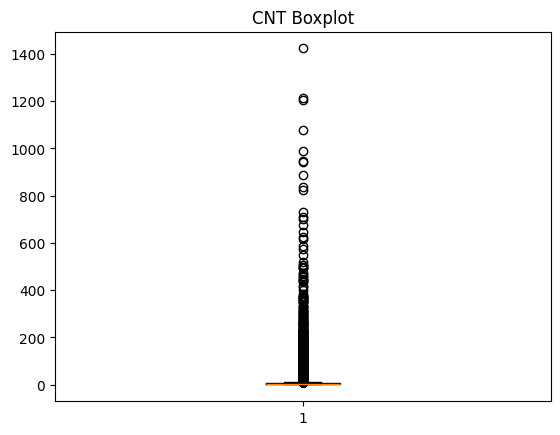

In [ ]:
# 일반 박스플롯으로 이상치 확인
plt.boxplot(df13['CNT'])
plt.title('CNT Boxplot')
plt.show()

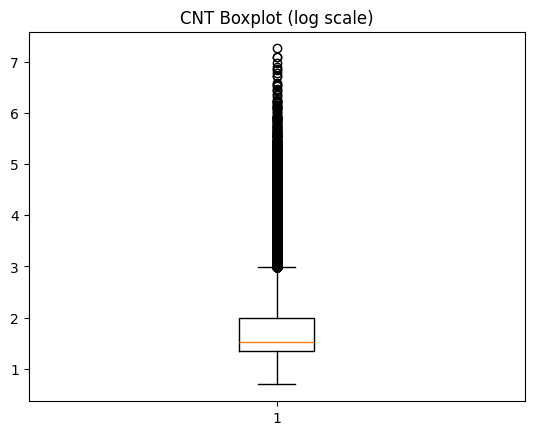

In [ ]:
plt.boxplot(np.log1p(df13['CNT']))
plt.title('CNT Boxplot (log scale)')
plt.show()

# cnt 이상치 결과 결론
CNT의 평균(7.34)과 중앙값(3.58)을 비교한 결과, 분포가 오른쪽으로 긴 형태(right-skewed)를 보았고, 특히 최대값(4256)이 상위 분위수(Q3=6.4) 대비 매우 크게 나타나면서, 일반 스케일의 박스플롯에서는 다수의 이상치로 보여지고있음.
하지만 로그 변환 후 분포를 확인한 결과, 극단값의 영향이 완화되었으며 데이터는 자연스러운 분포 형태를 보였고,
따라서 해당 값들은 제거해야 할 이상치라고 보기는 힘들어 보이고, 이동량 집계 데이터의 특성에서 발생한 값으로 판단됨.

- 이상치 제거 필요 없음
- 로그 변환 기반 분석 권장
- 데이터 품질 나쁘지 않음
- 결측치 처리만 해결하면 됨

# t13 범주 데이터 purpose(목적), sex_cd(성별), age_grp(나이) 확인

In [ ]:
# 목적 데이터부터 확인
con.execute("""
select purpose, count(*) as cnt
from read_parquet('../data/t13_2023_2025_all_clean.parquet')
            group by purpose
            order by cnt desc""").fetchdf()

,PURPOSE,cnt
0,6,116606681
1,0,98456437
2,1,54581952
3,2,5053207
4,3,3039365
5,5,1352525
6,4,906684


- 0(귀가) : 98456437
- 1(노선버스) : 54581952
- 2(지하철) : 5053207
- 3(도보) : 3039365
- 4(고속버스) : 906684
- 5(기차) : 1352525
- 6(항공) : 116606681
- 7(기타) : 데이터가 없음.

이거는 전화해서 물어보는걸로 그리고 공유드릴게요

In [ ]:
con.execute("""
SELECT
    PURPOSE,
    AVG(CNT) AS avg_cnt,
    COUNT(*) AS cnt
FROM read_parquet('../data/t13_2023_2025_all_clean.parquet')
GROUP BY PURPOSE
ORDER BY PURPOSE
""").fetchdf()

,PURPOSE,avg_cnt,cnt
0,0,7.448870,98456437
1,1,6.174638,54581952
2,2,11.116143,5053207
3,3,5.997345,3039365
4,4,3.545716,906684
5,5,4.587277,1352525
6,6,7.727620,116606681


이 데이터는 통신사 기반 유동인구 데이터로 보이고
PURPOSE는 내부 코드라 공식 정의가 없는 상태입니다

PURPOSE 변수는 이동 유형을 나타내는 코드값(0~6)으로 구성되어 있으나,
원본 데이터 설명 부재로 인해 각 코드의 정확한 의미는 확인되지 않았다.
따라서 본 분석에서는 해당 변수를 범주형 변수로 활용하고, 코드 간 상대적 비교 중심으로 해석하였다.

- 0(귀가) : 98456437 
- 1(노선버스) : 54581952 
- 2(지하철) : 5053207 
- 3(도보) : 3039365 
- 4(고속버스) : 906684 
- 5(기차) : 1352525 
- 6(항공) : 116606681 
- 7(기타) : 0
정확한 정보는 아님... 검색해서 알아본 정보

In [ ]:
con.execute("""
SELECT SEX_CD, COUNT(*) AS cnt
FROM read_parquet('../data/t13_2023_2025_all_clean.parquet')
GROUP BY SEX_CD
ORDER BY cnt DESC
""").fetchdf()

,SEX_CD,cnt
0,M,151193271
1,F,72175219
2,W,56628361


In [ ]:
con.execute("""
SELECT AGE_GRP, COUNT(*) AS cnt
FROM read_parquet('../data/t13_2023_2025_all_clean.parquet')
GROUP BY AGE_GRP
ORDER BY AGE_GRP
""").fetchdf()

,AGE_GRP,cnt
0,1,2256653
1,2,12433913
2,3,41585970
3,4,53177041
4,5,50959581
5,6,52824363
6,7,41849630
7,8,18806162
8,9,5682232
9,10,414067


In [ ]:
con.execute("""
SELECT
    PURPOSE,
    COUNT(*) AS cnt,
    COUNT(*) * 1.0 / SUM(COUNT(*)) OVER() AS ratio
FROM read_parquet('../data/t13_2023_2025_all_clean.parquet')
GROUP BY PURPOSE
ORDER BY cnt DESC
""").fetchdf()

,PURPOSE,cnt,ratio
0,6,116606681,0.416457
1,0,98456437,0.351634
2,1,54581952,0.194938
3,2,5053207,0.018047
4,3,3039365,0.010855
5,5,1352525,0.004831
6,4,906684,0.003238


In [ ]:
con.execute("""
SELECT
    SEX_CD,
    COUNT(*) AS cnt,
    COUNT(*) * 1.0 / SUM(COUNT(*)) OVER() AS sex_cnt
FROM read_parquet('../data/t13_2023_2025_all_clean.parquet')
GROUP BY SEX_CD
ORDER BY cnt DESC
""").fetchdf()

,SEX_CD,cnt,sex_cnt
0,M,151193271,0.539982
1,F,72175219,0.257772
2,W,56628361,0.202246


In [ ]:
con.execute("""
SELECT
    AGE_GRP,
    COUNT(*) AS cnt,
    COUNT(*) * 1.0 / SUM(COUNT(*)) OVER() AS age_cnt
FROM read_parquet('../data/t13_2023_2025_all_clean.parquet')
GROUP BY AGE_GRP
ORDER BY cnt DESC
""").fetchdf()

,AGE_GRP,cnt,age_cnt
0,4,53177041,1.899201e-01
1,6,52824363,1.886606e-01
2,5,50959581,1.820006e-01
3,7,41849630,1.494646e-01
4,3,41585970,1.485230e-01
5,8,18806162,6.716562e-02
6,2,12433913,4.440733e-02
7,9,5682232,2.029391e-02
8,1,2256653,8.059566e-03
9,10,414067,1.478827e-03


<Axes: xlabel='PURPOSE'>

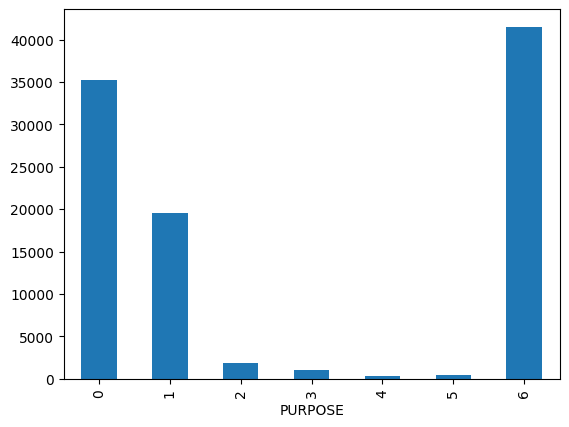

In [ ]:
df13 = con.execute("""
SELECT PURPOSE
FROM read_parquet('../data/t13_2023_2025_all_clean.parquet')
USING SAMPLE 100000
""").fetchdf()

df13['PURPOSE'].value_counts().sort_index().plot(kind='bar')

PURPOSE 변수의 분포를 확인한 결과, 특정 코드(6)에 데이터가 가장 많이 집중되어 있으며, 이후 0, 1 순으로 감소하는 형태를 보였다.
이는 전체 이동 데이터가 일부 특정 유형에 편중되어 있음을 의미하며, PURPOSE 변수 간 불균형이 존재하는 것으로 해석된다.

<Axes: xlabel='SEX_CD'>

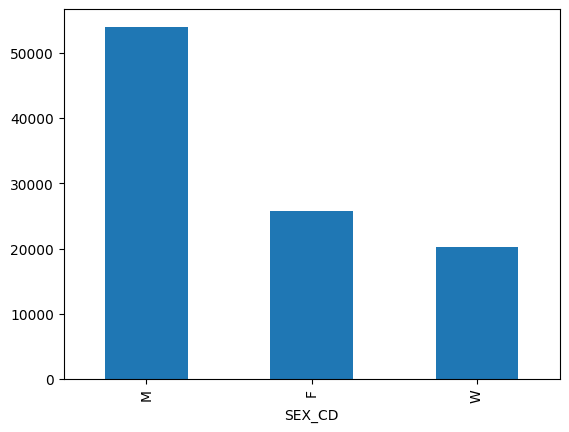

In [ ]:
df13 = con.execute("""
SELECT SEX_CD
FROM read_parquet('../data/t13_2023_2025_all_clean.parquet')
USING SAMPLE 100000
""").fetchdf()

df13['SEX_CD'].value_counts().plot(kind='bar')

남자의 비중이 가장 높았고 그다음 여자인데 차이가 심하다. 그리고 W는 찾아보니 통신사쪽 Unknown / 미확인 / 기타로 나타나 이게 20%나 되서 분석할때 따로 해봐야 할거 같습니다.

<Axes: xlabel='AGE_GRP'>

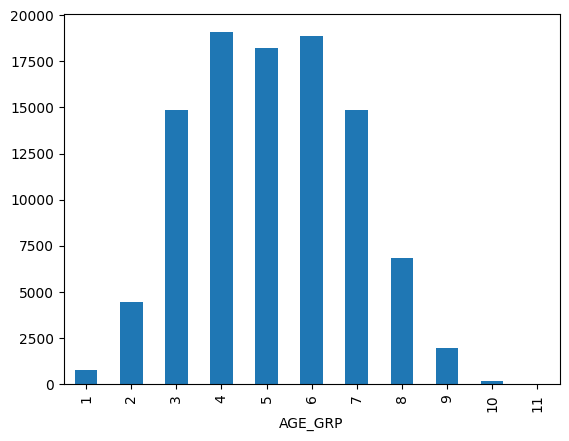

In [ ]:
df13 = con.execute("""
SELECT AGE_GRP
FROM read_parquet('../data/t13_2023_2025_all_clean.parquet')
USING SAMPLE 100000
""").fetchdf()

df13['AGE_GRP'].value_counts().sort_index().plot(kind='bar')

나이는 정규분포 형태를 띄고 있어 데이터에 이상이 없는것으로 보입니다. 4,5,6,7에 많이 몰려있는것으로 나타납니다. 유동인구 데이터에 적합한 느낌이 든다 나이가 많거나 적을수록 수가 적은거라서...

# T25 데이터

In [ ]:
path = "../data/t25_2023_2025_all.parquet"
con = duckdb.connect()
schema = con.execute(f"""
DESCRIBE SELECT * FROM read_parquet('{path}')
""").fetchdf()
schema

,column_name,column_type,null,key,default,extra
0,ETL_YMD,BIGINT,YES,None,None,None
1,DOW,VARCHAR,YES,None,None,None
2,O_TIME_CD,BIGINT,YES,None,None,None
3,O_CTY_CD,BIGINT,YES,None,None,None
4,O_MEGA_NM,VARCHAR,YES,None,None,None
5,O_CTY_NM,VARCHAR,YES,None,None,None
6,O_CENTER_X,BIGINT,YES,None,None,None
7,O_CENTER_Y,BIGINT,YES,None,None,None
8,D_TIME_CD,BIGINT,YES,None,None,None
9,D_CTY_CD,BIGINT,YES,None,None,None


동일 컬럼 데이터인줄 알았는데 같은 동일컬럼의 확장된 파일이었다....

# 공통(같은 유동인구 데이터는 맞음)
- ETL_YMD = 특정날짜
  출발 행정동/도착 행정동(예: O_ADMI_CD, O_ADMI_NM, D_ADMI_CD, D_ADMI_NM)
- PURPOSE = 목적
- SEX_CD = 성별
- AGE_GRP	= 연령대
- CNT	= 이동량 및 집계값들
# 추가 된 것
- O_TIME_CD (출발 시간)
- D_TIME_CD (도착 시간)
- DOW (요일)

즉 이전 13데이터보다 더 정확해진 데이터(시간 기반으로 분석 가능, 언제 얼마나 이동했는지 13은 얼마나 이동했는지만)

In [ ]:
# 날짜 확인
con.execute("""
select
    min(ETL_YMD) AS min_date,
    max(ETL_YMD) AS max_date,
    count(*) AS row_cnt,
    count(ETL_YMD) AS non_null_date
from read_parquet('../data/t25_2023_2025_all.parquet')
""").fetchdf()

,min_date,max_date,row_cnt,non_null_date
0,20230101,20251231,261148533,261148533


In [ ]:
# 날짜 컬럼이 BIGINT 형태이므로 분석을 위해 DATE 타입으로 변환
con.execute("""
COPY (
    SELECT
        CAST(STRPTIME(CAST(ETL_YMD AS VARCHAR), '%Y%m%d') AS DATE) AS ETL_YMD,
        *
    EXCLUDE (ETL_YMD)
    FROM read_parquet('../data/t25_2023_2025_all.parquet')
)
TO '../data/t25_2023_2025_all_clean.parquet' (FORMAT PARQUET);
""")

In [ ]:
con.execute("""
SELECT MIN(ETL_YMD), MAX(ETL_YMD)
FROM read_parquet('../data/t25_2023_2025_all_clean.parquet')
""").fetchdf()

,min(ETL_YMD),max(ETL_YMD)
0,2023-01-01,2025-12-31


In [ ]:
# 타입 확인
con.execute("""
describe select *
from read_parquet('../data/t25_2023_2025_all_clean.parquet')""").fetchdf()

,column_name,column_type,null,key,default,extra
0,ETL_YMD,DATE,YES,None,None,None
1,DOW,VARCHAR,YES,None,None,None
2,O_TIME_CD,BIGINT,YES,None,None,None
3,O_CTY_CD,BIGINT,YES,None,None,None
4,O_MEGA_NM,VARCHAR,YES,None,None,None
5,O_CTY_NM,VARCHAR,YES,None,None,None
6,O_CENTER_X,BIGINT,YES,None,None,None
7,O_CENTER_Y,BIGINT,YES,None,None,None
8,D_TIME_CD,BIGINT,YES,None,None,None
9,D_CTY_CD,BIGINT,YES,None,None,None


In [ ]:
con.execute("""
SELECT ETL_YMD
FROM read_parquet('../data/t25_2023_2025_all_clean.parquet')
LIMIT 5
""").fetchdf()

,ETL_YMD
0,2023-01-06
1,2023-01-08
2,2023-01-14
3,2023-01-16
4,2023-01-25


# 컬럼 결측 확인

In [ ]:
con.execute("""
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN ETL_YMD IS NULL THEN 1 ELSE 0 END) AS etl_ymd_null,
    SUM(CASE WHEN DOW IS NULL THEN 1 ELSE 0 END) AS dow_null,
    SUM(CASE WHEN O_TIME_CD IS NULL THEN 1 ELSE 0 END) AS o_time_null,
    SUM(CASE WHEN O_CTY_CD IS NULL THEN 1 ELSE 0 END) AS o_cty_cd_null,
    SUM(CASE WHEN O_MEGA_NM IS NULL THEN 1 ELSE 0 END) AS o_mega_null,
    SUM(CASE WHEN O_CTY_NM IS NULL THEN 1 ELSE 0 END) AS o_cty_null,
    SUM(CASE WHEN O_CENTER_X IS NULL THEN 1 ELSE 0 END) AS o_x_null,
    SUM(CASE WHEN O_CENTER_Y IS NULL THEN 1 ELSE 0 END) AS o_y_null,
    SUM(CASE WHEN D_TIME_CD IS NULL THEN 1 ELSE 0 END) AS d_time_null,
    SUM(CASE WHEN D_CTY_CD IS NULL THEN 1 ELSE 0 END) AS d_cty_cd_null,
    SUM(CASE WHEN D_MEGA_NM IS NULL THEN 1 ELSE 0 END) AS d_mega_null,
    SUM(CASE WHEN D_CTY_NM IS NULL THEN 1 ELSE 0 END) AS d_cty_null,
    SUM(CASE WHEN D_CENTER_X IS NULL THEN 1 ELSE 0 END) AS d_x_null,
    SUM(CASE WHEN D_CENTER_Y IS NULL THEN 1 ELSE 0 END) AS d_y_null,
    SUM(CASE WHEN PURPOSE IS NULL THEN 1 ELSE 0 END) AS purpose_null,
    SUM(CASE WHEN TRANS_GB IS NULL THEN 1 ELSE 0 END) AS trans_null,
    SUM(CASE WHEN SEX_CD IS NULL THEN 1 ELSE 0 END) AS sex_null,
    SUM(CASE WHEN AGE_GRP IS NULL THEN 1 ELSE 0 END) AS age_null,
    SUM(CASE WHEN CNT IS NULL THEN 1 ELSE 0 END) AS cnt_null
FROM read_parquet('../data/t25_2023_2025_all_clean.parquet')
""").fetchdf()

,total_rows,etl_ymd_null,dow_null,o_time_null,o_cty_cd_null,o_mega_null,o_cty_null,o_x_null,o_y_null,d_time_null,d_cty_cd_null,d_mega_null,d_cty_null,d_x_null,d_y_null,purpose_null,trans_null,sex_null,age_null,cnt_null
0,261148533,0.0,0.0,0.0,0.0,4.0,120422.0,4.0,4.0,0.0,0.0,11.0,119701.0,11.0,11.0,0.0,0.0,0.0,0.0,0.0


결측 확인 결과
- O_MEGA_NM: 4건 (출발 광역시도명)
- O_CTY_NM: 120,422건 (출발 시군구명)
- O_CENTER_X/Y: 각 4건 (출발 좌표)
- D_MEGA_NM: 11건 (도착 광역시도명)
- D_CTY_NM: 119,701건 (도착 시군구명)
- D_CENTER_X/Y: 각 11건 (도착 좌표)

In [3]:
con.execute("""
SELECT *
FROM read_parquet('../data/t25_2023_2025_all_clean.parquet')
WHERE O_CTY_NM IS NULL 
""").fetchdf()

,ETL_YMD,DOW,O_TIME_CD,O_CTY_CD,O_MEGA_NM,O_CTY_NM,O_CENTER_X,O_CENTER_Y,D_TIME_CD,D_CTY_CD,D_MEGA_NM,D_CTY_NM,D_CENTER_X,D_CENTER_Y,PURPOSE,TRANS_GB,SEX_CD,AGE_GRP,CNT
0,2023-01-04,수,13,36110,세종특별자치시,None,978411,1840347,16,41135,경기도,성남시 분당구,965120,1931210,0,5,M,3,2.27
1,2023-01-23,월,12,36110,세종특별자치시,None,978411,1840347,14,41133,경기도,성남시 중원구,970268,1937199,0,0,M,7,4.50
2,2023-01-08,일,18,36110,세종특별자치시,None,978411,1840347,20,41135,경기도,성남시 분당구,965120,1931210,0,0,M,7,2.90
3,2023-01-29,일,9,36110,세종특별자치시,None,978411,1840347,11,41135,경기도,성남시 분당구,965120,1931210,6,0,M,3,4.50
4,2023-01-19,목,13,36110,세종특별자치시,None,978411,1840347,15,41135,경기도,성남시 분당구,965120,1931210,6,0,M,7,2.47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120417,2025-12-31,수,20,36110,세종특별자치시,None,978410,1840345,22,41135,경기도,성남시 분당구,965120,1931210,6,0,M,7,1.21
120418,2025-12-31,수,20,36110,세종특별자치시,None,978410,1840345,23,41135,경기도,성남시 분당구,965120,1931210,6,0,F,6,3.53
120419,2025-12-31,수,21,36110,세종특별자치시,None,978410,1840345,22,41133,경기도,성남시 중원구,970268,1937199,0,0,M,8,3.38
120420,2025-12-31,수,21,36110,세종특별자치시,None,978410,1840345,22,41135,경기도,성남시 분당구,965120,1931210,0,0,F,5,2.87


In [4]:
con.execute("""
SELECT *
FROM read_parquet('../data/t25_2023_2025_all_clean.parquet')
WHERE D_CTY_NM IS NULL 
""").fetchdf()

,ETL_YMD,DOW,O_TIME_CD,O_CTY_CD,O_MEGA_NM,O_CTY_NM,O_CENTER_X,O_CENTER_Y,D_TIME_CD,D_CTY_CD,D_MEGA_NM,D_CTY_NM,D_CENTER_X,D_CENTER_Y,PURPOSE,TRANS_GB,SEX_CD,AGE_GRP,CNT
0,2023-01-22,일,7,41135,경기도,성남시 분당구,965120,1931210,9,36110,세종특별자치시,None,978411,1840347,6,0,M,6,3.30
1,2023-01-03,화,6,41135,경기도,성남시 분당구,965120,1931210,8,36110,세종특별자치시,None,978411,1840347,1,0,M,6,6.87
2,2023-01-01,일,14,41135,경기도,성남시 분당구,965120,1931210,16,36110,세종특별자치시,None,978411,1840347,6,0,M,7,2.85
3,2023-01-28,토,11,41135,경기도,성남시 분당구,965120,1931210,13,36110,세종특별자치시,None,978411,1840347,6,0,M,6,3.74
4,2023-01-14,토,15,41135,경기도,성남시 분당구,965120,1931210,17,36110,세종특별자치시,None,978411,1840347,0,0,M,7,2.43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119696,2025-12-31,수,21,41131,경기도,성남시 수정구,964981,1937423,22,36110,세종특별자치시,None,978410,1840345,0,0,M,5,2.88
119697,2025-12-31,수,21,41131,경기도,성남시 수정구,964981,1937423,22,36110,세종특별자치시,None,978410,1840345,6,0,F,3,2.07
119698,2025-12-31,수,21,41135,경기도,성남시 분당구,965120,1931210,22,36110,세종특별자치시,None,978410,1840345,0,0,F,5,3.25
119699,2025-12-31,수,21,41135,경기도,성남시 분당구,965120,1931210,22,36110,세종특별자치시,None,978410,1840345,0,0,M,2,3.79


In [6]:
con.execute("""
SELECT *
FROM read_parquet('../data/t25_2023_2025_all_clean.parquet')
WHERE O_MEGA_NM IS NULL 
""").fetchdf()

,ETL_YMD,DOW,O_TIME_CD,O_CTY_CD,O_MEGA_NM,O_CTY_NM,O_CENTER_X,O_CENTER_Y,D_TIME_CD,D_CTY_CD,D_MEGA_NM,D_CTY_NM,D_CENTER_X,D_CENTER_Y,PURPOSE,TRANS_GB,SEX_CD,AGE_GRP,CNT
0,2024-05-19,일,15,99,None,None,<NA>,<NA>,15,41135,경기도,성남시 분당구,965120,1931210,1,0,W,6,3.62
1,2024-05-19,일,15,99,None,None,<NA>,<NA>,15,41135,경기도,성남시 분당구,965120,1931210,1,0,M,6,2.96
2,2024-05-21,화,11,99,None,None,<NA>,<NA>,12,41131,경기도,성남시 수정구,964981,1937423,0,0,W,4,2.63
3,2024-05-21,화,11,99,None,None,<NA>,<NA>,12,41131,경기도,성남시 수정구,964981,1937423,0,0,M,4,2.84


In [7]:
con.execute("""
SELECT *
FROM read_parquet('../data/t25_2023_2025_all_clean.parquet')
WHERE D_MEGA_NM IS NULL 
""").fetchdf()

,ETL_YMD,DOW,O_TIME_CD,O_CTY_CD,O_MEGA_NM,O_CTY_NM,O_CENTER_X,O_CENTER_Y,D_TIME_CD,D_CTY_CD,D_MEGA_NM,D_CTY_NM,D_CENTER_X,D_CENTER_Y,PURPOSE,TRANS_GB,SEX_CD,AGE_GRP,CNT
0,2024-05-18,토,17,41135,경기도,성남시 분당구,965120,1931210,19,99,None,None,<NA>,<NA>,0,0,W,7,3.50
1,2024-05-18,토,17,41135,경기도,성남시 분당구,965120,1931210,19,99,None,None,<NA>,<NA>,0,0,M,8,3.50
2,2024-05-19,일,15,41135,경기도,성남시 분당구,965120,1931210,16,99,None,None,<NA>,<NA>,6,0,W,7,2.61
3,2024-05-19,일,15,41135,경기도,성남시 분당구,965120,1931210,16,99,None,None,<NA>,<NA>,6,0,W,6,2.57
4,2024-05-20,월,14,41135,경기도,성남시 분당구,965120,1931210,16,99,None,None,<NA>,<NA>,0,0,W,7,3.50
5,2024-05-20,월,14,41135,경기도,성남시 분당구,965120,1931210,16,99,None,None,<NA>,<NA>,0,0,M,8,3.50
6,2024-05-31,금,12,41135,경기도,성남시 분당구,965120,1931210,13,99,None,None,<NA>,<NA>,6,0,M,7,3.17
7,2024-05-31,금,12,41135,경기도,성남시 분당구,965120,1931210,13,99,None,None,<NA>,<NA>,6,0,M,5,1.94
8,2024-05-18,토,8,41131,경기도,성남시 수정구,964981,1937423,9,99,None,None,<NA>,<NA>,6,0,M,4,2.84
9,2024-05-18,토,8,41131,경기도,성남시 수정구,964981,1937423,9,99,None,None,<NA>,<NA>,6,0,W,4,2.63


생긴 결측들 느낌이
위치 매핑 실패 일부
좌표/행정코드 연결 오류

컬럼 확인 후 다시 공유

## t25 데이터 결론
- 전체 행: 261,148,533	
- 날짜, 코드, CNT, 성별, 연령, 목적 -> 결측 0
- 행정명/좌표 컬럼에만 결측 존재(t13에서 데이터구조만 다르고 패턴은 동일)

t25는 세종시부분말고는 4건 11건이 99코드로 되어있어 세종시만 unknown으로 매핑 후 확인 및 최종 전처리 완료로 끝

In [26]:
con.execute("""
COPY (
    SELECT
        * EXCLUDE (O_CTY_NM),

        CASE
            WHEN O_MEGA_NM = '세종특별자치시'
                THEN 'UNKNOWN'
            ELSE O_CTY_NM
        END AS O_CTY_NM

    FROM read_parquet('../data/t25_2023_2025_all_clean.parquet')
)
TO '../data/t25_2023_2025_all_final.parquet'
(FORMAT PARQUET);
""")

In [27]:
con.execute("""
SELECT
    O_MEGA_NM,
    O_CTY_NM,
    COUNT(*) AS cnt
FROM read_parquet('../data/t25_2023_2025_all_final.parquet')
WHERE O_MEGA_NM = '세종특별자치시'
GROUP BY 1, 2
ORDER BY cnt DESC;
""").fetchdf()

,O_MEGA_NM,O_CTY_NM,cnt
0,세종특별자치시,UNKNOWN,120418


출발지 unknown으로 매핑 잘된걸로 확인 나머지4개는 99코드

도착지의 세종특별자치시 none값을 unknown으로 매핑

In [29]:
con.execute("""
COPY (
    SELECT
        * EXCLUDE (D_CTY_NM),

        CASE
            WHEN D_MEGA_NM = '세종특별자치시'
                THEN 'UNKNOWN'
            ELSE D_CTY_NM
        END AS D_CTY_NM

    FROM read_parquet('../data/t25_2023_2025_all_final.parquet')
)
TO '../data/t25_2023_2025_all_final_v2.parquet'
(FORMAT PARQUET);
""")

In [30]:
con.execute("""
SELECT
    D_MEGA_NM,
    D_CTY_NM,
    COUNT(*) AS cnt
FROM read_parquet('../data/t25_2023_2025_all_final_v2.parquet')
WHERE D_MEGA_NM = '세종특별자치시'
GROUP BY 1, 2
ORDER BY cnt DESC;
""").fetchdf()

,D_MEGA_NM,D_CTY_NM,cnt
0,세종특별자치시,UNKNOWN,119690


매핑 잘되었고 11개는 99코드

In [31]:
con.execute("""
SELECT *
FROM read_parquet('../data/t25_2023_2025_all_final_v2.parquet')
WHERE D_MEGA_NM IS NULL 
""").fetchdf()

,ETL_YMD,DOW,O_TIME_CD,O_CTY_CD,O_MEGA_NM,O_CENTER_X,O_CENTER_Y,D_TIME_CD,D_CTY_CD,D_MEGA_NM,D_CENTER_X,D_CENTER_Y,PURPOSE,TRANS_GB,SEX_CD,AGE_GRP,CNT,O_CTY_NM,D_CTY_NM
0,2024-05-18,토,17,41135,경기도,965120,1931210,19,99,None,<NA>,<NA>,0,0,W,7,3.50,성남시 분당구,None
1,2024-05-18,토,17,41135,경기도,965120,1931210,19,99,None,<NA>,<NA>,0,0,M,8,3.50,성남시 분당구,None
2,2024-05-19,일,15,41135,경기도,965120,1931210,16,99,None,<NA>,<NA>,6,0,W,7,2.61,성남시 분당구,None
3,2024-05-19,일,15,41135,경기도,965120,1931210,16,99,None,<NA>,<NA>,6,0,W,6,2.57,성남시 분당구,None
4,2024-05-20,월,14,41135,경기도,965120,1931210,16,99,None,<NA>,<NA>,0,0,W,7,3.50,성남시 분당구,None
5,2024-05-20,월,14,41135,경기도,965120,1931210,16,99,None,<NA>,<NA>,0,0,M,8,3.50,성남시 분당구,None
6,2024-05-31,금,12,41135,경기도,965120,1931210,13,99,None,<NA>,<NA>,6,0,M,7,3.17,성남시 분당구,None
7,2024-05-31,금,12,41135,경기도,965120,1931210,13,99,None,<NA>,<NA>,6,0,M,5,1.94,성남시 분당구,None
8,2024-05-18,토,8,41131,경기도,964981,1937423,9,99,None,<NA>,<NA>,6,0,M,4,2.84,성남시 수정구,None
9,2024-05-18,토,8,41131,경기도,964981,1937423,9,99,None,<NA>,<NA>,6,0,W,4,2.63,성남시 수정구,None


# t25 이상치 확인

In [ ]:
con.execute("""
summarize
            select cnt
from read_parquet('../data/t25_2023_2025_all_clean.parquet')""").fetchdf()

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,CNT,DOUBLE,0.93,2949.68,61899,7.814062583602681,18.362718148389607,2.8694057095916317,3.684104422895171,6.821572307804122,261148533,0.0


- min: 0.93
- max: 2949.68
- 평균: 7.81
- 중앙값: 3.68
- Q25: 2.86
- q50: 3.68
- q75: 6.82
- 표준편차: 18.36
t13이랑 똑같이 오른쪽으로 긴 분포로 뛴다 평균 중앙값 결과 여진히 max값이 2949로 큰값이 존재해 일반 박스플롯으로 하면 이상치로 나타날 수 있어 로그변환 후 박스플롯해서 확인해봐야됨

In [ ]:
# 데이터가 너무커 100000행으로 샘플데이터로 확인해봄
df25 = con.execute("""
SELECT CNT
FROM read_parquet('../data/t25_2023_2025_all_clean.parquet')
USING SAMPLE 100000
""").fetchdf()

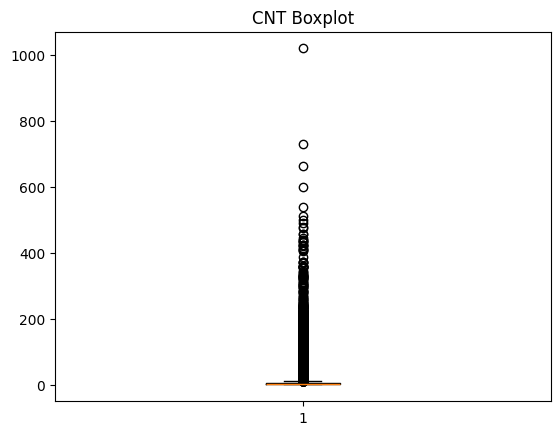

In [ ]:
# 일반 박스플롯으로 이상치 확인(비교)
plt.boxplot(df25['CNT'])
plt.title('CNT Boxplot')
plt.show()

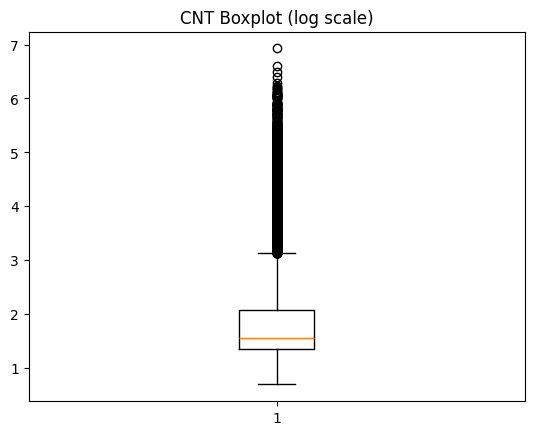

In [ ]:
plt.boxplot(np.log1p(df25['CNT']))
plt.title('CNT Boxplot (log scale)')
plt.show()

t25 cnt 이상치 결과
t25 데이터의 CNT 분포는 t13과 유사하게 평균이 중앙값보다 크게 나타나며, 오른쪽으로 긴 분포(right-skewed)를 보였다.
또한 최대값(2949.68)이 상위 분위수(Q3=6.82) 대비 크게 나타나 일부 큰 값이 존재하며, 일반 스케일의 박스플롯에서는 이상치로 표현될 수 있다.
그러나 이는 유동인구 이동량 데이터의 특성에서 기인한 자연스러운 현상으로 판단되며, 분포를 보다 정확히 파악하기 위해 로그 변환 후 시각화를 수행하는 것이 적절하다. 따라서 해당 값들은 제거 대상이 아닌, 유동인구 이동량 데이터의 특성을 반영한 자연스러운 값으로 판단된다.

# t25 범주형 데이터(PURPOSE,TRANS_GB(이동수단 핵심), SEX_CD, AGE_GRP) 이상치 확인

In [ ]:
con.execute("""
SELECT
    PURPOSE,
    COUNT(*) AS cnt,
    COUNT(*) * 1.0 / SUM(COUNT(*)) OVER() AS ratio
FROM read_parquet('../data/t25_2023_2025_all_clean.parquet')
GROUP BY PURPOSE
ORDER BY cnt DESC
""").fetchdf()

,PURPOSE,cnt,ratio
0,6,118569558,0.454031
1,0,91768356,0.351403
2,1,40207598,0.153964
3,2,4944132,0.018932
4,3,3555872,0.013616
5,5,1312100,0.005024
6,4,790917,0.003029


6 = 0.45
0 = 0.35
1 = 0.15로 3개가 95%정도로 차지함
해석결과 소수 목적이 대부분의 이동을 차지

In [ ]:
con.execute("""
SELECT
    TRANS_GB,
    COUNT(*) AS cnt,
    COUNT(*) * 1.0 / SUM(COUNT(*)) OVER() AS ratio
FROM read_parquet('../data/t25_2023_2025_all_clean.parquet')
GROUP BY TRANS_GB
ORDER BY cnt DESC
""").fetchdf()

,TRANS_GB,cnt,ratio
0,0,134024205,0.513211
1,2,52098972,0.199499
2,1,39759084,0.152247
3,3,18118192,0.069379
4,7,16320232,0.062494
5,5,538725,0.002063
6,4,189553,0.000726
7,6,99570,0.000381


이동수단 이동목적 같이 공유

0 = 0.51
2 = 0.19
1 = 0.15로 이동유형에서도 약 80%이상의 비중을 차지 특히 0번 0.51로 50%이상 차지 시간분석 및 연령분석때 사용하면 될듯?

In [ ]:
con.execute("""
SELECT
    SEX_CD,
    COUNT(*) AS cnt,
    COUNT(*) * 1.0 / SUM(COUNT(*)) OVER() AS ratio
FROM read_parquet('../data/t25_2023_2025_all_clean.parquet')
GROUP BY SEX_CD
ORDER BY cnt DESC
""").fetchdf()

,SEX_CD,cnt,ratio
0,M,141075097,0.540210
1,F,63642580,0.243703
2,W,56430856,0.216087


M(남자) → 54%
F(기타) → 24%
W(여자) → 21% t13에서도 보았듯이 F가 약24%로 나와 유심히 살펴봐야할듯 합니다.

In [ ]:
con.execute("""
SELECT
    AGE_GRP,
    COUNT(*) AS cnt,
    COUNT(*) * 1.0 / SUM(COUNT(*)) OVER() AS ratio
FROM read_parquet('../data/t25_2023_2025_all_clean.parquet')
GROUP BY AGE_GRP
ORDER BY AGE_GRP
""").fetchdf()

,AGE_GRP,cnt,ratio
0,1,2247081,8.604609e-03
1,2,13071962,5.005566e-02
2,3,39667971,1.518981e-01
3,4,47680432,1.825797e-01
4,5,45848172,1.755636e-01
5,6,47835683,1.831742e-01
6,7,39907302,1.528146e-01
7,8,18724400,7.170019e-02
8,9,5733913,2.195652e-02
9,10,424191,1.624328e-03


t13이랑 동일하게 중간연령대에서 약 70%정도 활동량이 높다는 결과로 해석됨

<Axes: xlabel='PURPOSE'>

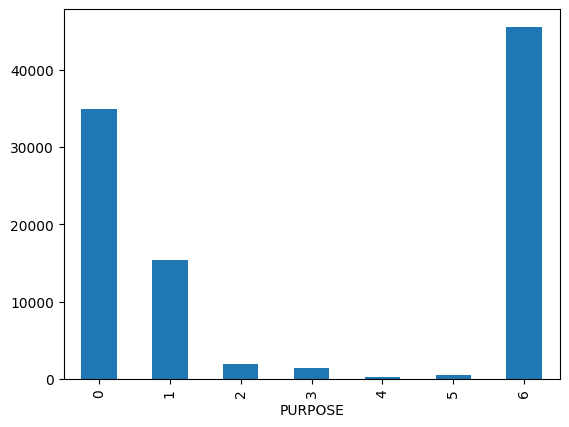

In [ ]:
# 수랑 비율본걸 시각화(샘플데이터 100000으로 추출 후)
df25 = con.execute("""
SELECT PURPOSE
FROM read_parquet('../data/t25_2023_2025_all_clean.parquet')
USING SAMPLE 100000
""").fetchdf()

df25['PURPOSE'].value_counts().sort_index().plot(kind='bar')

<Axes: xlabel='TRANS_GB'>

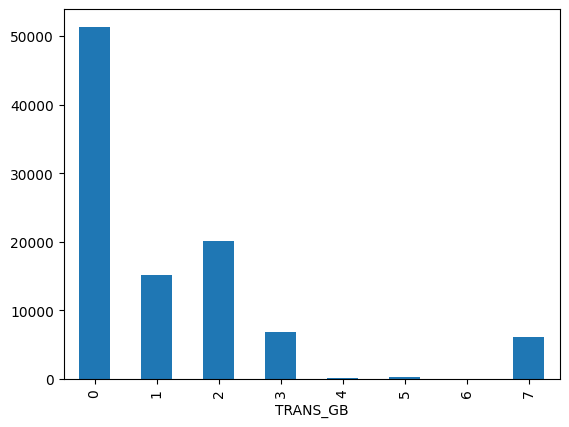

In [ ]:
df25 = con.execute("""
SELECT TRANS_GB
FROM read_parquet('../data/t25_2023_2025_all_clean.parquet')
USING SAMPLE 100000
""").fetchdf()

df25['TRANS_GB'].value_counts().sort_index().plot(kind='bar')

알아보고

<Axes: xlabel='SEX_CD'>

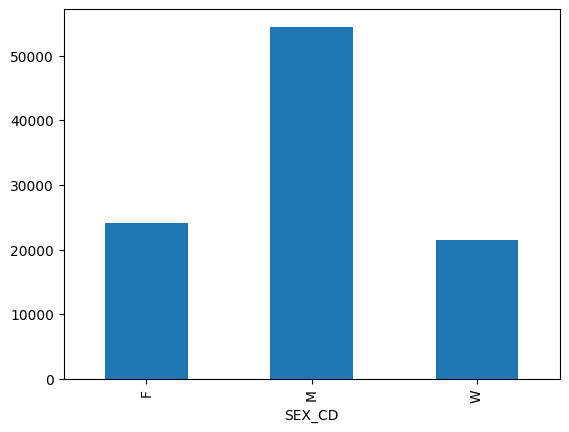

In [ ]:
df25 = con.execute("""
SELECT SEX_CD
FROM read_parquet('../data/t25_2023_2025_all_clean.parquet')
USING SAMPLE 100000
""").fetchdf()

df25['SEX_CD'].value_counts().sort_index().plot(kind='bar')

<Axes: xlabel='AGE_GRP'>

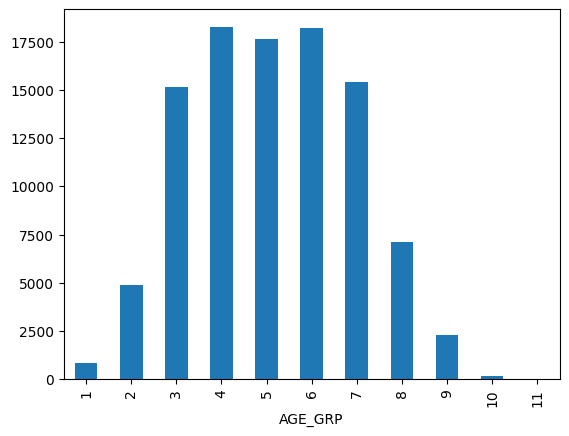

In [ ]:
df25 = con.execute("""
SELECT AGE_GRP
FROM read_parquet('../data/t25_2023_2025_all_clean.parquet')
USING SAMPLE 100000
""").fetchdf()

df25['AGE_GRP'].value_counts().sort_index().plot(kind='bar')

확실히 나이쪽은 중간쪽이 높아서 정규분포 형태를 뜀 주요그룹중심으로 접근하는 방법도 좋을 듯??
지금까지 t13 t25확인결과 분석 시 컬럼들 사용할때 이상 없음
t13과 t25는 합칠 수있긴한데 컬럼이 추가된걸 맞춘후 합치거나 해야됨

# t26 데이터 확인

In [ ]:
path = "../data/t26_2023_2025_all_fixed.parquet"
con = duckdb.connect()
schema = con.execute(f"""
DESCRIBE SELECT * FROM read_parquet('{path}')
""").fetchdf()
schema

,column_name,column_type,null,key,default,extra
0,ETL_YMD,BIGINT,YES,None,None,None
1,DOW,VARCHAR,YES,None,None,None
2,D_TIME_CD,VARCHAR,YES,None,None,None
3,D_ADMI_CD,BIGINT,YES,None,None,None
4,D_MEGA_NM,VARCHAR,YES,None,None,None
5,D_CTY_NM,VARCHAR,YES,None,None,None
6,D_ADMI_NM,VARCHAR,YES,None,None,None
7,D_CENTER_X,BIGINT,YES,None,None,None
8,D_CENTER_Y,BIGINT,YES,None,None,None
9,PURPOSE,BIGINT,YES,None,None,None


하... 다다른 데이터였음.... t26은 도착기준 + 체류시간 포함 데이터
- t13/ t25는 이동데이터(어디에서 어디로 이동 그리고 얼마나 이동했는지)
- t26은 체류 데이터(얼마나 머물렀는지 어디에 얼마나 있었는지)

In [ ]:
# 날짜 확인
con.execute("""
select
    min(ETL_YMD) AS min_date,
    max(ETL_YMD) AS max_date,
    count(*) AS row_cnt,
    count(ETL_YMD) AS non_null_date
from read_parquet('../data/t26_2023_2025_all_fixed.parquet')
""").fetchdf()

,min_date,max_date,row_cnt,non_null_date
0,20230101,20251231,258637442,258637442


전체 행: 258637442
날짜는 max까지 이상 무

In [ ]:
# 날짜 컬럼이 BIGINT 형태이므로 분석을 위해 DATE 타입으로 변환
con.execute("""
COPY (
    SELECT
        CAST(STRPTIME(CAST(ETL_YMD AS VARCHAR), '%Y%m%d') AS DATE) AS ETL_YMD,
        *
    EXCLUDE (ETL_YMD)
    FROM read_parquet('../data/t26_2023_2025_all_fixed.parquet')
)
TO '../data/t26_2023_2025_all_clean.parquet' (FORMAT PARQUET);
""")

In [ ]:
con.execute("""
SELECT MIN(ETL_YMD), MAX(ETL_YMD)
FROM read_parquet('../data/t26_2023_2025_all_clean.parquet')
""").fetchdf()

,min(ETL_YMD),max(ETL_YMD)
0,2023-01-01,2025-12-31


In [ ]:
# 타입 확인
con.execute("""
describe select *
from read_parquet('../data/t26_2023_2025_all_clean.parquet')""").fetchdf()

,column_name,column_type,null,key,default,extra
0,ETL_YMD,DATE,YES,None,None,None
1,DOW,VARCHAR,YES,None,None,None
2,D_TIME_CD,VARCHAR,YES,None,None,None
3,D_ADMI_CD,BIGINT,YES,None,None,None
4,D_MEGA_NM,VARCHAR,YES,None,None,None
5,D_CTY_NM,VARCHAR,YES,None,None,None
6,D_ADMI_NM,VARCHAR,YES,None,None,None
7,D_CENTER_X,BIGINT,YES,None,None,None
8,D_CENTER_Y,BIGINT,YES,None,None,None
9,PURPOSE,BIGINT,YES,None,None,None


In [ ]:
con.execute("""
SELECT ETL_YMD
FROM read_parquet('../data/t25_2023_2025_all_clean.parquet')
LIMIT 5
""").fetchdf()

,ETL_YMD
0,2023-01-06
1,2023-01-08
2,2023-01-14
3,2023-01-16
4,2023-01-25


In [ ]:
con.execute("""
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN ETL_YMD IS NULL THEN 1 ELSE 0 END) AS etl_ymd_null,
    SUM(CASE WHEN DOW IS NULL THEN 1 ELSE 0 END) AS dow_null,
    SUM(CASE WHEN D_TIME_CD IS NULL THEN 1 ELSE 0 END) AS d_time_null,
    SUM(CASE WHEN D_ADMI_CD IS NULL THEN 1 ELSE 0 END) AS d_admi_cd_null,
    SUM(CASE WHEN D_MEGA_NM IS NULL THEN 1 ELSE 0 END) AS d_mega_null,
    SUM(CASE WHEN D_CTY_NM IS NULL THEN 1 ELSE 0 END) AS d_cty_null,
    SUM(CASE WHEN D_ADMI_NM IS NULL THEN 1 ELSE 0 END) AS d_admi_null,
    SUM(CASE WHEN D_CENTER_X IS NULL THEN 1 ELSE 0 END) AS d_x_null,
    SUM(CASE WHEN D_CENTER_Y IS NULL THEN 1 ELSE 0 END) AS d_y_null,
    SUM(CASE WHEN PURPOSE IS NULL THEN 1 ELSE 0 END) AS purpose_null,
    SUM(CASE WHEN TRANS_GB IS NULL THEN 1 ELSE 0 END) AS trans_null,
    SUM(CASE WHEN DURATION IS NULL THEN 1 ELSE 0 END) AS duration_null,
    SUM(CASE WHEN SEX_CD IS NULL THEN 1 ELSE 0 END) AS sex_null,
    SUM(CASE WHEN AGE_GRP IS NULL THEN 1 ELSE 0 END) AS age_null,
    SUM(CASE WHEN CNT IS NULL THEN 1 ELSE 0 END) AS cnt_null
FROM read_parquet('../data/t26_2023_2025_all_clean.parquet')
""").fetchdf()

,total_rows,etl_ymd_null,dow_null,d_time_null,d_admi_cd_null,d_mega_null,d_cty_null,d_admi_null,d_x_null,d_y_null,purpose_null,trans_null,duration_null,sex_null,age_null,cnt_null
0,258637442,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


- 와 t26은 결측이 없어서 바로 이상치 확인만 하면 됨
- 전체행 258637442중 날짜, 시간, 지역, 목적, 이동유형, 체류시간, 성별, 연령, CNT까지 전부 값이 있음

# t26은 CNT 분포
DURATION 분포
범주형(PURPOSE, TRANS_GB, SEX_CD, AGE_GRP) 이상치 확인

In [ ]:
# cnt 확인
con.execute("""
summarize
            select cnt
from read_parquet('../data/t26_2023_2025_all_clean.parquet')""").fetchdf()

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,CNT,DOUBLE,0.93,1893.67,25094,5.576381867396108,6.814879335466783,2.7856152785576183,3.5083276188034427,5.916319340990913,258637442,0.0


- min: 0.93
- max: 1893.67
- 평균: 5.57
- 중앙값: 3.51
- Q25: 2.78
- q50: 3.50
- q75: 5.91
- 표준편차: 6.81

역시 중앙값보다 평균값이 커서 오른쪽으로 긴 분포 형태를 나타낼거 같음 rmflrh duwjsgl 분위수보다 max값이 1893으로 커서 일반 박스플롯으론 이상치 존재로 판별 할수도 있다고 판단해서 로그변환 후 박스플롯 찍어보기

체류 데이터는 이동 데이터보다 더 안정적인 분포를 가질거 같음 max값이 그래도 다른데이터에 비해 낮음

In [149]:
# 데이터가 너무커 100000행으로 샘플데이터로 확인해봄
df26 = con.execute("""
SELECT CNT, duration
FROM read_parquet('../data/t26_2023_2025_all_clean.parquet')
USING SAMPLE 100000
""").fetchdf()

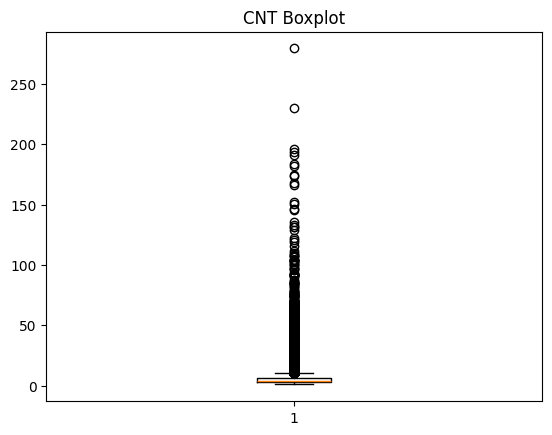

In [111]:
# 일반 박스플롯으로 이상치 확인(비교)
plt.boxplot(df26['CNT'])
plt.title('CNT Boxplot')
plt.show()

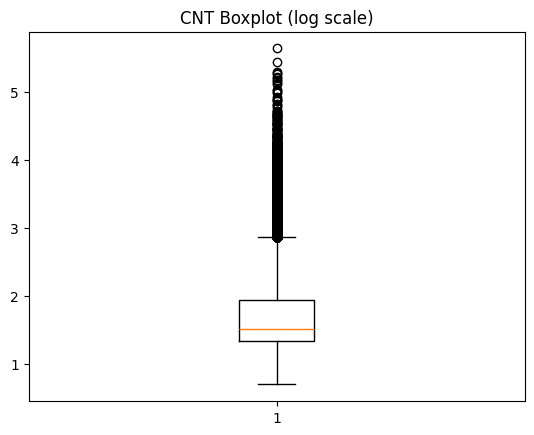

In [ ]:
plt.boxplot(np.log1p(df26['CNT']))
plt.title('CNT Boxplot (log scale)')
plt.show()

로그 변환 후 박스플롯 해보니 이상치는 보이지 않음
극단값의 영향이 완화

이제 duration(체류시간) 컬럼 확인

In [ ]:
# duration 확인
con.execute("""
summarize
            select duration
from read_parquet('../data/t26_2023_2025_all_clean.parquet')""").fetchdf()

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,DURATION,DOUBLE,30.0,1440.0,85819,257.6491619467874,211.2328121533335,90.0,180.0,359.0649112698998,258637442,0.0


- min: 30
- max: 1440
- 중앙값: 180(약3시간)
- Q25: 90
- q50: 180
- q75: 359

음... 최소 30분이상은 체류한다 중앙값이 180인걸 보야 대부분 3시간은 있는다로 보여짐 그리고 max:1440인걸보아 24시간이 최대로 보여짐 이미 정제된??
결론 짦게는 30분 길게는 24시간 이걸로 지역이랑 비교하면 좋을듯??

이것도 오른쪽으로 긴 분포형이라 로그변환후 확인

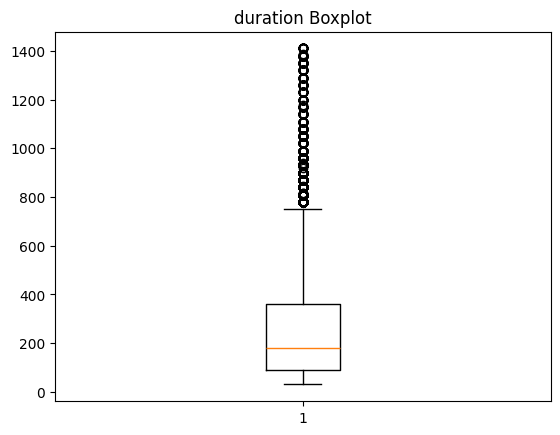

In [120]:
# 일반 박스플롯으로 이상치 확인(비교)
plt.boxplot(df26['DURATION'])
plt.title('duration Boxplot')
plt.show()

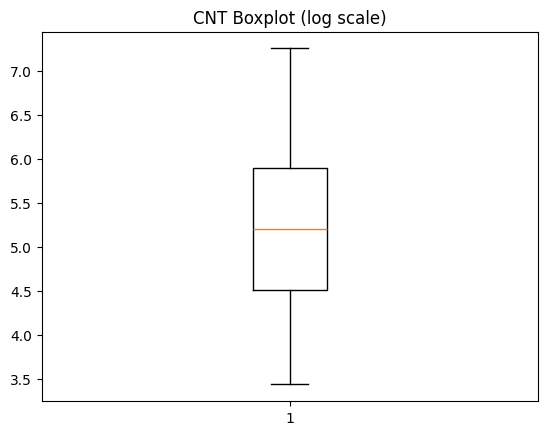

In [ ]:
plt.boxplot(np.log1p(df26['DURATION']))
plt.title('CNT Boxplot (log scale)')
plt.show()

?????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????

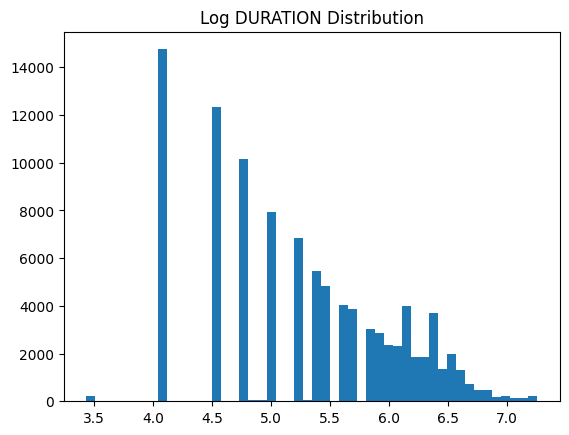

In [ ]:
plt.hist(np.log1p(df26['DURATION']), bins=50)
plt.title('Log DURATION Distribution')
plt.show()

음... 체류시간 보는건 박스플롯으로 하면 안되는구나....

로그 변환된 DURATION의 히스토그램을 확인한 결과, 약 log 값 4.0 부근에 데이터가 집중된 것으로 나타났다. 이를 실제 체류시간으로 환산하면 약 50~60분 수준에 해당

# 이제 범주형 데이터 4개 확인

In [129]:
con.execute("""
SELECT
    PURPOSE,
    COUNT(*) AS cnt,
    COUNT(*) * 1.0 / SUM(COUNT(*)) OVER() AS ratio
FROM read_parquet('../data/t26_2023_2025_all_clean.parquet')
GROUP BY PURPOSE
ORDER BY cnt DESC
""").fetchdf()

,PURPOSE,cnt,ratio
0,6,111701230,0.431883
1,0,92097142,0.356086
2,1,45213775,0.174815
3,2,6582245,0.025450
4,3,2127315,0.008225
5,5,915735,0.003541


6 = 0.43
0 = 0.35
1 = 0.17 T26도 약 95%이상 차지 T25랑 비슷함

In [130]:
con.execute("""
SELECT
    TRANS_GB,
    COUNT(*) AS cnt,
    COUNT(*) * 1.0 / SUM(COUNT(*)) OVER() AS ratio
FROM read_parquet('../data/t26_2023_2025_all_clean.parquet')
GROUP BY TRANS_GB
ORDER BY cnt DESC
""").fetchdf()

,TRANS_GB,cnt,ratio
0,0,90173706,0.348649
1,1,58031120,0.224372
2,3,50997740,0.197178
3,2,34970019,0.135209
4,7,23965156,0.092659
5,5,409763,0.001584
6,6,63115,0.000244
7,4,26823,0.000104


0 = 0.34
1 = 0.22
3 = 0.19
2 = 0.13
7 = 0.09로 5개의 이동수단이 과반수 차지 극 소수만 다른걸 이용

In [131]:
con.execute("""
SELECT
    SEX_CD,
    COUNT(*) AS cnt,
    COUNT(*) * 1.0 / SUM(COUNT(*)) OVER() AS ratio
FROM read_parquet('../data/t26_2023_2025_all_clean.parquet')
GROUP BY SEX_CD
ORDER BY cnt DESC
""").fetchdf()

,SEX_CD,cnt,ratio
0,M,129681499,0.501403
1,F,76337187,0.295151
2,W,52618756,0.203446


똑같이 w가 0.20으로 나와 뺄 수는 없을거 같음 다포함해서 연령대별 확인하는게 좋을거 같음

In [132]:
con.execute("""
SELECT
    AGE_GRP,
    COUNT(*) AS cnt,
    COUNT(*) * 1.0 / SUM(COUNT(*)) OVER() AS ratio
FROM read_parquet('../data/t26_2023_2025_all_clean.parquet')
GROUP BY AGE_GRP
ORDER BY cnt DESC
""").fetchdf()

,AGE_GRP,cnt,ratio
0,6,28612031,1.106260e-01
1,5,26893341,1.039808e-01
2,4,26161429,1.011510e-01
3,7,24066955,9.305287e-02
4,3,21907911,8.470510e-02
5,06,19147584,7.403253e-02
6,04,17536760,6.780441e-02
7,05,17516283,6.772524e-02
8,07,17073735,6.601417e-02
9,03,14099327,5.451387e-02


AGE_GRP에서 06,04등 으로 인해 문자열로 되어있어 값이 서로다른값으로 찍힘 그래서 형변환을해 정리 해줘야 할듯

In [137]:
con.execute("""
SELECT
    CAST(AGE_GRP AS INTEGER) AS AGE_GRP,
    COUNT(*) AS cnt,
    COUNT(*) * 1.0 / SUM(COUNT(*)) OVER() AS ratio
FROM read_parquet('../data/t26_2023_2025_all_clean.parquet')
GROUP BY AGE_GRP
ORDER BY AGE_GRP
""").fetchdf()

,AGE_GRP,cnt,ratio
0,1,1669244,6.453992e-03
1,1,982208,3.797625e-03
2,2,10795512,4.173994e-02
3,2,7191439,2.780510e-02
4,3,14099327,5.451387e-02
5,3,21907911,8.470510e-02
6,4,17536760,6.780441e-02
7,4,26161429,1.011510e-01
8,5,26893341,1.039808e-01
9,5,17516283,6.772524e-02


같은 숫자 2번씩 나오네 하...

In [148]:
con.execute("""
SELECT
    CAST(TRIM(AGE_GRP) AS INTEGER) AS AGE_GRP,
    COUNT(*) AS cnt,
    COUNT(*) * 1.0 / SUM(COUNT(*)) OVER() AS ratio
FROM read_parquet('../data/t26_2023_2025_all_clean.parquet')
GROUP BY CAST(TRIM(AGE_GRP) AS INTEGER)
ORDER BY AGE_GRP
""").fetchdf()

,AGE_GRP,cnt,ratio
0,1,2651452,1.025162e-02
1,2,17986951,6.954504e-02
2,3,36007238,1.392190e-01
3,4,43698189,1.689554e-01
4,5,44409624,1.717061e-01
5,6,47759615,1.846585e-01
6,7,41140690,1.590670e-01
7,8,19079834,7.377058e-02
8,9,5553200,2.147098e-02
9,10,345003,1.333925e-03


AGE_GRP 변수는 문자열 형식으로 저장되면서 동일한 연령 구간이 중복 표기된 문제가 있었으나, 정수형으로 변환하여 통합한 결과 정상적인 분포를 확인할 수 있었다.
분석 결과, 중간 연령대(4~7 구간)에 데이터가 집중되어 있으며 특히 5~6 구간의 비중이 가장 높게 나타났다. 이는 체류 데이터 역시 활동량이 높은 주요 연령대 중심으로 구성되어 있음을 보여준다. 중간 연령대 집중 구조 똑같음 위에랑

<Axes: xlabel='PURPOSE'>

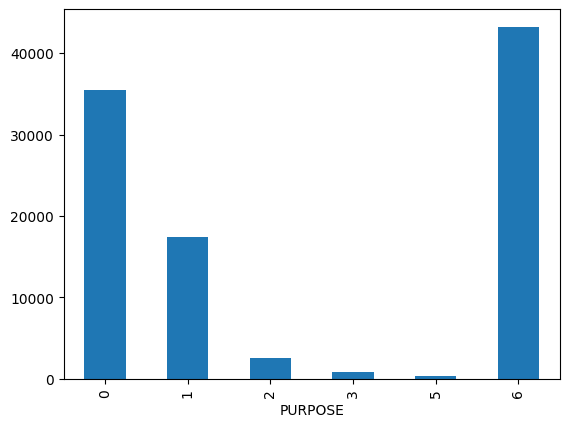

In [145]:
# 수랑 비율본걸 시각화(샘플데이터 100000으로 추출 후)
df26 = con.execute("""
SELECT PURPOSE
FROM read_parquet('../data/t26_2023_2025_all_clean.parquet')
USING SAMPLE 100000
""").fetchdf()

df26['PURPOSE'].value_counts().sort_index().plot(kind='bar')

<Axes: xlabel='TRANS_GB'>

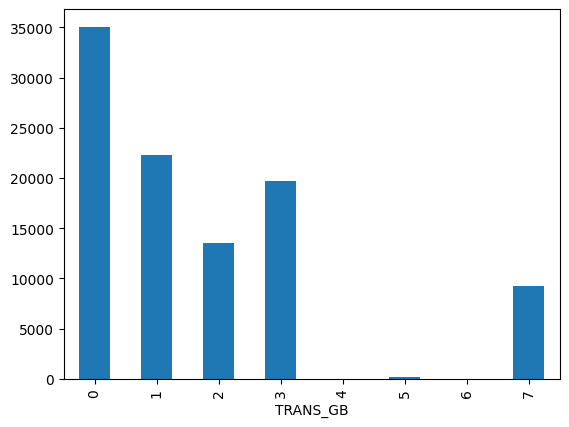

In [144]:
df26 = con.execute("""
SELECT TRANS_GB
FROM read_parquet('../data/t26_2023_2025_all_clean.parquet')
USING SAMPLE 100000
""").fetchdf()

df26['TRANS_GB'].value_counts().sort_index().plot(kind='bar')

<Axes: xlabel='SEX_CD'>

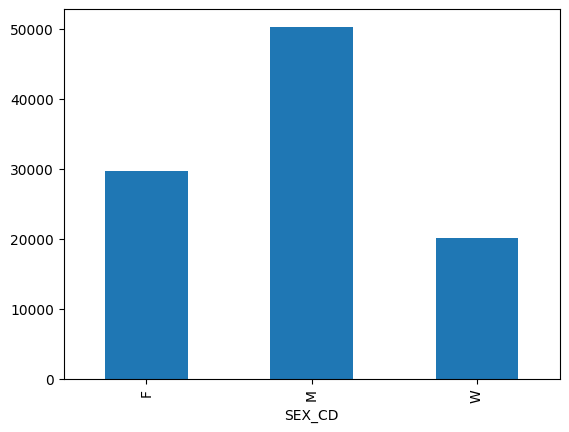

In [146]:
df26 = con.execute("""
SELECT SEX_CD
FROM read_parquet('../data/t26_2023_2025_all_clean.parquet')
USING SAMPLE 100000
""").fetchdf()

df26['SEX_CD'].value_counts().sort_index().plot(kind='bar')

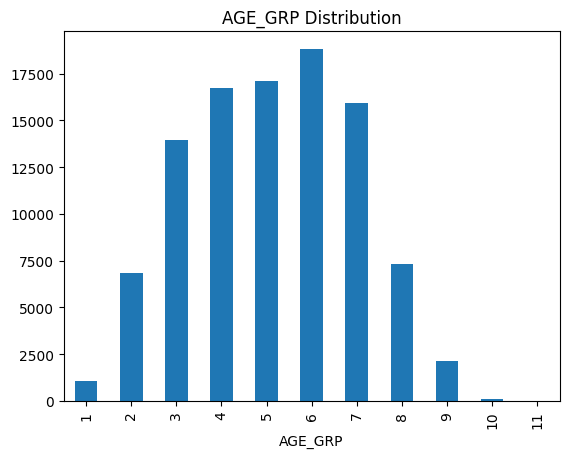

In [151]:
df26['AGE_GRP'] = df26['AGE_GRP'].astype(str).str.strip().str.lstrip('0')
df26['AGE_GRP'] = df26['AGE_GRP'].replace('', '0').astype(int)

df26['AGE_GRP'].value_counts().sort_index().plot(kind='bar')
plt.title('AGE_GRP Distribution')
plt.show()

In [152]:
# agb_grp 문자열 정리 후 integer로 통합 원본은 남기고 1차 전처리 final(T26)
con.execute("""
COPY (
    SELECT
        CAST(TRIM(AGE_GRP) AS INTEGER) AS AGE_GRP,
        *
    EXCLUDE (AGE_GRP)
    FROM read_parquet('../data/t26_2023_2025_all_clean.parquet')
)
TO '../data/t26_2023_2025_all_final.parquet' (FORMAT PARQUET);
""")

In [153]:
con.execute("""
SELECT
    AGE_GRP,
    COUNT(*) AS cnt,
    COUNT(*) * 1.0 / SUM(COUNT(*)) OVER() AS ratio
FROM read_parquet('../data/t26_2023_2025_all_final.parquet')
GROUP BY AGE_GRP
ORDER BY cnt DESC
""").fetchdf()

,AGE_GRP,cnt,ratio
0,6,47759615,1.846585e-01
1,5,44409624,1.717061e-01
2,4,43698189,1.689554e-01
3,7,41140690,1.590670e-01
4,3,36007238,1.392190e-01
5,8,19079834,7.377058e-02
6,2,17986951,6.954504e-02
7,9,5553200,2.147098e-02
8,1,2651452,1.025162e-02
9,10,345003,1.333925e-03


t26 형변환까지 완료 후 final 저장

결론: t26은 체류시간 즉 이지역에 얼마나 머물러있나의 데이터이고 t13 t25랑은 직접적으로 파일연결 불가 하지만 분석적으로는 이동 데이터랑 체류데이터로 스토리 이어서 가능 어디로 많이 이동했고 이동한 곳에서 얼마나 머물렀는지로 그리고 t26데이터는 결측이 없어 분석하는데 이상 없음 이상치도 따로 발견 된건 없음

# T27 데이터

In [ ]:
path = "../data/t27_2023_2025_all.parquet"

con = duckdb.connect()

schema = con.execute(f"""
DESCRIBE SELECT * FROM read_parquet('{path}')
""").fetchdf()

schema

,column_name,column_type,null,key,default,extra
0,ETL_YMD,BIGINT,YES,None,None,None
1,DOW,VARCHAR,YES,None,None,None
2,O_TIME_CD,VARCHAR,YES,None,None,None
3,O_ADMI_CD,BIGINT,YES,None,None,None
4,O_MEGA_NM,VARCHAR,YES,None,None,None
5,O_CTY_NM,VARCHAR,YES,None,None,None
6,O_ADMI_NM,VARCHAR,YES,None,None,None
7,O_CENTER_X,BIGINT,YES,None,None,None
8,O_CENTER_Y,BIGINT,YES,None,None,None
9,PURPOSE,BIGINT,YES,None,None,None


T26이랑 같은 동일컬럼의 데이터이고 이상치 및 결측치 확인후 데이터 유니온해 T26~27파일 생성해도 될거 같음

In [157]:
# 일단 날짜 확인
con.execute("""
select
    min(ETL_YMD) AS min_date,
    max(ETL_YMD) AS max_date,
    count(*) AS row_cnt,
    count(ETL_YMD) AS non_null_date
from read_parquet('../data/t27_2023_2025_all.parquet')
""").fetchdf()

,min_date,max_date,row_cnt,non_null_date
0,20230101,20251231,278322883,278322883


전체 행: 278322883

In [158]:
# 날짜 컬럼이 BIGINT 형태이므로 분석을 위해 DATE 타입으로 변환
con.execute("""
COPY (
    SELECT
        CAST(STRPTIME(CAST(ETL_YMD AS VARCHAR), '%Y%m%d') AS DATE) AS ETL_YMD,
        *
    EXCLUDE (ETL_YMD)
    FROM read_parquet('../data/t27_2023_2025_all.parquet')
)
TO '../data/t27_2023_2025_all_clean.parquet' (FORMAT PARQUET);
""")

In [159]:
con.execute("""
SELECT MIN(ETL_YMD), MAX(ETL_YMD)
FROM read_parquet('../data/t27_2023_2025_all_clean.parquet')
""").fetchdf()

,min(ETL_YMD),max(ETL_YMD)
0,2023-01-01,2025-12-31


In [160]:
# 타입 확인
con.execute("""
describe select *
from read_parquet('../data/t27_2023_2025_all_clean.parquet')""").fetchdf()

,column_name,column_type,null,key,default,extra
0,ETL_YMD,DATE,YES,None,None,None
1,DOW,VARCHAR,YES,None,None,None
2,O_TIME_CD,VARCHAR,YES,None,None,None
3,O_ADMI_CD,BIGINT,YES,None,None,None
4,O_MEGA_NM,VARCHAR,YES,None,None,None
5,O_CTY_NM,VARCHAR,YES,None,None,None
6,O_ADMI_NM,VARCHAR,YES,None,None,None
7,O_CENTER_X,BIGINT,YES,None,None,None
8,O_CENTER_Y,BIGINT,YES,None,None,None
9,PURPOSE,BIGINT,YES,None,None,None


In [161]:
con.execute("""
SELECT ETL_YMD
FROM read_parquet('../data/t27_2023_2025_all_clean.parquet')
LIMIT 5
""").fetchdf()

,ETL_YMD
0,2023-01-13
1,2023-01-03
2,2023-01-10
3,2023-01-26
4,2023-01-10


In [163]:
# 똑같이 결측확인
con.execute("""
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN ETL_YMD IS NULL THEN 1 ELSE 0 END) AS etl_ymd_null,
    SUM(CASE WHEN DOW IS NULL THEN 1 ELSE 0 END) AS dow_null,
    SUM(CASE WHEN O_TIME_CD IS NULL THEN 1 ELSE 0 END) AS o_time_null,
    SUM(CASE WHEN O_ADMI_CD IS NULL THEN 1 ELSE 0 END) AS o_admi_cd_null,
    SUM(CASE WHEN O_MEGA_NM IS NULL THEN 1 ELSE 0 END) AS o_mega_null,
    SUM(CASE WHEN O_CTY_NM IS NULL THEN 1 ELSE 0 END) AS o_cty_null,
    SUM(CASE WHEN O_ADMI_NM IS NULL THEN 1 ELSE 0 END) AS o_admi_null,
    SUM(CASE WHEN O_CENTER_X IS NULL THEN 1 ELSE 0 END) AS o_x_null,
    SUM(CASE WHEN O_CENTER_Y IS NULL THEN 1 ELSE 0 END) AS o_y_null,
    SUM(CASE WHEN PURPOSE IS NULL THEN 1 ELSE 0 END) AS purpose_null,
    SUM(CASE WHEN TRANS_GB IS NULL THEN 1 ELSE 0 END) AS trans_null,
    SUM(CASE WHEN DURATION IS NULL THEN 1 ELSE 0 END) AS duration_null,
    SUM(CASE WHEN SEX_CD IS NULL THEN 1 ELSE 0 END) AS sex_null,
    SUM(CASE WHEN AGE_GRP IS NULL THEN 1 ELSE 0 END) AS age_null,
    SUM(CASE WHEN CNT IS NULL THEN 1 ELSE 0 END) AS cnt_null
FROM read_parquet('../data/t27_2023_2025_all_clean.parquet')
""").fetchdf()

,total_rows,etl_ymd_null,dow_null,o_time_null,o_admi_cd_null,o_mega_null,o_cty_null,o_admi_null,o_x_null,o_y_null,purpose_null,trans_null,duration_null,sex_null,age_null,cnt_null
0,278322883,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


결측 없음 이상치 확인 후 데이터 통합

똑같이 cnt부터 이상치 확인(boxplot까지)

In [164]:
# cnt 확인
con.execute("""
summarize
            select cnt
from read_parquet('../data/t27_2023_2025_all_clean.parquet')""").fetchdf()

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,CNT,DOUBLE,0.93,1224.41,23911,5.063320251171474,5.7963383086595215,2.738732142914508,3.490543159207513,5.3238597392635345,278322883,0.0


동일컬럼에 행 다름
- min: 0.93
- max: 1224
- 평균: 5.06
- 표준편차: 5.79
확실히 이동데이터보단 체류데이터가 더 안정적인 패턴을 가지고 있음 표준편차가 크지 않음
27 데이터의 CNT 분포를 확인한 결과, 기존 t25 및 t26과 유사한 분포 형태를 보이며, 평균과 표준편차 수준에서도 큰 차이를 보이지 않았다.
이는 동일한 기준으로 수집된 데이터로 판단되며, 구조 및 성격이 일관된 데이터로 볼 수 있다. 따라서 컬럼 구조가 동일한 다른 데이터와의 통합이 가능한 형태로 판단.

In [165]:
# 데이터가 너무커 100000행으로 샘플데이터로 확인해봄
df27 = con.execute("""
SELECT CNT, duration
FROM read_parquet('../data/t27_2023_2025_all_clean.parquet')
USING SAMPLE 100000
""").fetchdf()

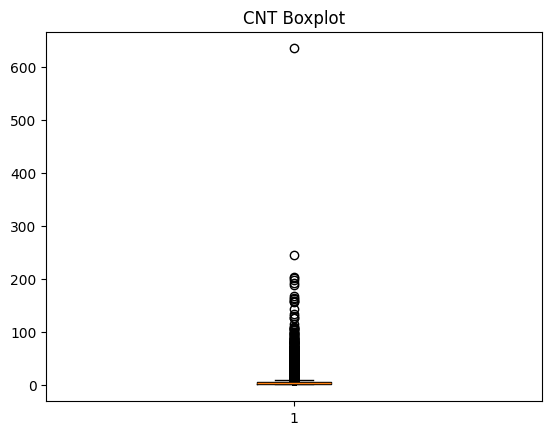

In [166]:
# 일반 박스플롯으로 이상치 확인(비교)
plt.boxplot(df27['CNT'])
plt.title('CNT Boxplot')
plt.show()

값이 큰게 1개 있는거 같아 로그변한 후에도 확인

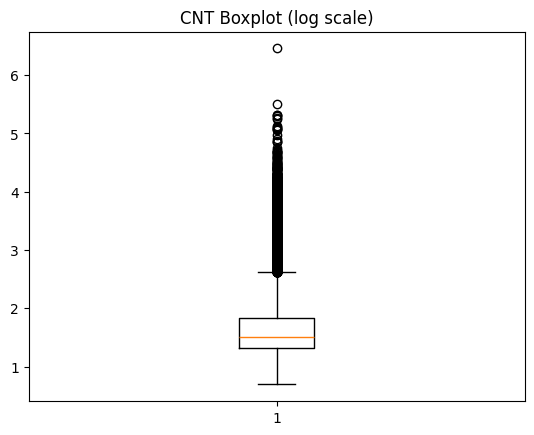

In [168]:
# 로그변환 박스플롯
plt.boxplot(np.log1p(df27['CNT']))
plt.title('CNT Boxplot (log scale)')
plt.show()

로그 변환 후 박스플롯에서도 일부 이상치가 관찰되었으나, 이는 데이터 오류가 아닌 분포 특성에 의해 발생한 상대적으로 큰 값으로 판단된다.
해당 값들은 유동인구 데이터의 자연스러운 변동 범위에 포함되며, 별도의 이상치 제거 없이 분석에 활용하는 것이 적절하다.

In [169]:
# duration 확인
con.execute("""
summarize
            select duration
from read_parquet('../data/t27_2023_2025_all_clean.parquet')""").fetchdf()

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,DURATION,DOUBLE,30.0,1440.0,76769,253.3812231397853,205.31894815470937,90.0,180.01576757232465,355.9015625333394,278322883,0.0


duration도 t26이랑 동일한 걸로 확인 min30.0 max1440으로 일치

- 항목	t26	      t27
- min	30	      30
- max  1440	     1440
- 평균 ~257	     ~253
- 중앙값 ~180	 ~180
- Q3   ~360	     ~356
- std  ~211	     ~205

동일 분포로 봐도 무방함

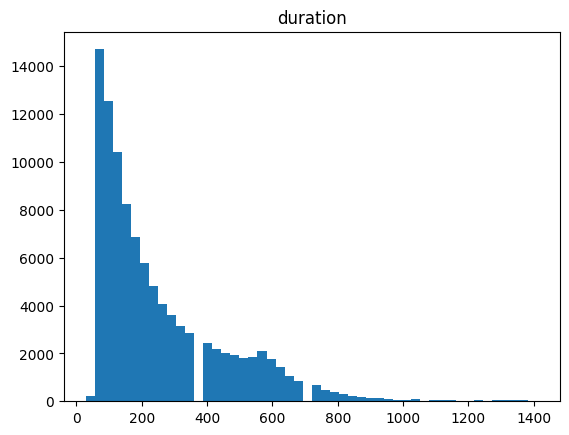

In [ ]:
# 일반 hist
plt.hist(df27['DURATION'], bins=50)
plt.title('duration')
plt.show()

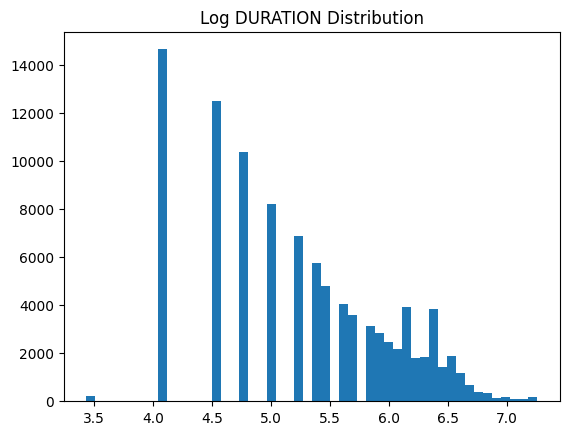

In [175]:
# 로그 변환 후 hist
plt.hist(np.log1p(df27['DURATION']), bins=50)
plt.title('Log DURATION Distribution')
plt.show()

DURATION 변수에 대해 일반 스케일과 로그 변환 스케일에서 분포를 비교한 결과, 모두에서 데이터의 전반적인 분포 구조를 확인할 수 있었다.
로그 변환 시 분포가 보다 안정적으로 나타나기는 하나, 일반 스케일에서도 극단적인 이상치로 판단되는 값은 발견되지 않았으며, 체류시간 특성에 따른 자연스러운 분포로 해석

t13,t25,t26,27은
- 이동 → 체류 연결
- 지역 분석
- 행동 패턴

확인 결과: t26,t27은 합할 예정이었으나 도착이랑 출발이 나눠져있어 합쳤다가 데이터가 꼬일 수 있어 그대로 두고 분석하는게 좋다고 판단됨.
t26은 도착 기준의 체류 데이터를 중심으로 구성된 반면, t27은 출발 기준의 이동 데이터를 포함하고 있어 동일한 기준으로 직접 통합할 경우 데이터 해석이 왜곡될 가능성이 존재

In [176]:
con.execute("""
SELECT PURPOSE, COUNT(*) AS cnt,
COUNT(*) * 1.0 / SUM(COUNT(*)) OVER() AS ratio
FROM read_parquet('../data/t27_2023_2025_all_clean.parquet')
GROUP BY PURPOSE
ORDER BY cnt DESC
""").fetchdf()

,PURPOSE,cnt,ratio
0,6,121584293,0.436846
1,0,100031605,0.359408
2,1,46826103,0.168244
3,2,6164205,0.022148
4,3,2520575,0.009056
5,4,651467,0.002341
6,5,544635,0.001957


PURPOSE, TRANS_GB: 공식 정의 없음 → 추정 기반 분석

In [177]:
con.execute("""
SELECT TRANS_GB, COUNT(*) AS cnt,
COUNT(*) * 1.0 / SUM(COUNT(*)) OVER() AS ratio
FROM read_parquet('../data/t27_2023_2025_all_clean.parquet')
GROUP BY TRANS_GB
ORDER BY cnt DESC
""").fetchdf()

,TRANS_GB,cnt,ratio
0,0,98935177,0.355469
1,1,62179546,0.223408
2,3,54517621,0.195879
3,2,38149282,0.137068
4,7,24172214,0.086850
5,5,182657,0.000656
6,4,174569,0.000627
7,6,11817,0.000042


In [178]:
con.execute("""
SELECT SEX_CD, COUNT(*) AS cnt,
COUNT(*) * 1.0 / SUM(COUNT(*)) OVER() AS ratio
FROM read_parquet('../data/t27_2023_2025_all_clean.parquet')
GROUP BY SEX_CD
ORDER BY cnt DESC
""").fetchdf()

,SEX_CD,cnt,ratio
0,M,139992624,0.502986
1,F,81466345,0.292704
2,W,56863914,0.204309


SEX_CD = W: 미확인 코드 → 기타로 유지

In [179]:
con.execute("""
SELECT AGE_GRP, COUNT(*) AS cnt,
COUNT(*) * 1.0 / SUM(COUNT(*)) OVER() AS ratio
FROM read_parquet('../data/t27_2023_2025_all_clean.parquet')
GROUP BY AGE_GRP
ORDER BY cnt DESC
""").fetchdf()

,AGE_GRP,cnt,ratio
0,6,31185208,1.120469e-01
1,5,29244662,1.050746e-01
2,4,28504514,1.024153e-01
3,7,26040655,9.356275e-02
4,3,23350017,8.389543e-02
5,06,20581293,7.394754e-02
6,04,19138071,6.876212e-02
7,05,18910093,6.794300e-02
8,07,18311746,6.579317e-02
9,03,15424835,5.542065e-02


In [181]:
# agb_grp 문자열 정리 후 integer로 통합 원본은 남기고 1차 전처리 final(T26)마찬가지로 정리 후 이상치 확인
con.execute("""
COPY (
    SELECT
        CAST(TRIM(AGE_GRP) AS INTEGER) AS AGE_GRP,
        *
    EXCLUDE (AGE_GRP)
    FROM read_parquet('../data/t27_2023_2025_all_clean.parquet')
)
TO '../data/t27_2023_2025_all_final.parquet' (FORMAT PARQUET);
""")

In [183]:
con.execute("""
SELECT
    AGE_GRP,
    COUNT(*) AS cnt,
    COUNT(*) * 1.0 / SUM(COUNT(*)) OVER() AS ratio
FROM read_parquet('../data/t27_2023_2025_all_final.parquet')
GROUP BY AGE_GRP
ORDER BY cnt DESC
""").fetchdf()

,AGE_GRP,cnt,ratio
0,6,51766501,1.859944e-01
1,5,48154755,1.730176e-01
2,4,47642585,1.711774e-01
3,7,44352401,1.593559e-01
4,3,38774852,1.393161e-01
5,8,20029185,7.196385e-02
6,2,18972293,6.816649e-02
7,9,5616530,2.017991e-02
8,1,2673071,9.604209e-03
9,10,335390,1.205039e-03


In [6]:
# 이제 각 정리한 전처리 파일 중복값 확인
con.execute("""
SELECT COALESCE(SUM(cnt - 1), 0) AS duplicated_rows
FROM (
    SELECT
        ETL_YMD, O_ADMI_CD, O_MEGA_NM, O_CTY_NM, O_ADMI_NM,
        O_CENTER_X, O_CENTER_Y,
        D_ADMI_CD, D_MEGA_NM, D_CTY_NM, D_ADMI_NM,
        D_CENTER_X, D_CENTER_Y,
        PURPOSE, SEX_CD, AGE_GRP, CNT,
        COUNT(*) AS cnt
    FROM read_parquet('../data/t13_2023_2025_all_clean.parquet')
    GROUP BY ALL
    HAVING COUNT(*) > 1
) AS dup
""").fetchdf()

,duplicated_rows
0,0.0


중복 없음.

- duplicate_groups: 중복 패턴 종류 수
- total_rows_in_duplicate_groups: 중복이 발생한 그룹들에 포함된 전체 행 수
- duplicated_rows: 실제 제거 대상 중복 행 수

In [7]:
con.execute("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(*) - COUNT(DISTINCT (
        ETL_YMD, DOW, O_TIME_CD, O_CTY_CD,
        O_MEGA_NM, O_CTY_NM, O_CENTER_X, O_CENTER_Y,
        D_TIME_CD, D_CTY_CD, D_MEGA_NM, D_CTY_NM,
        D_CENTER_X, D_CENTER_Y,
        PURPOSE, TRANS_GB, SEX_CD, AGE_GRP, CNT
    )) AS duplicated_rows
FROM read_parquet('../data/t25_2023_2025_all_clean.parquet')
""").fetchdf()

,total_rows,duplicated_rows
0,261148533,0


In [8]:
con.execute("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(*) - COUNT(DISTINCT (
        ETL_YMD, DOW, D_TIME_CD, D_ADMI_CD,
        D_MEGA_NM, D_CTY_NM, D_ADMI_NM,
        D_CENTER_X, D_CENTER_Y,
        PURPOSE, TRANS_GB, DURATION,
        SEX_CD, AGE_GRP, CNT
    )) AS duplicated_rows
FROM read_parquet('../data/t26_2023_2025_all_final.parquet')
""").fetchdf()

,total_rows,duplicated_rows
0,258637442,0


In [ ]:
con.execute("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(*) - COUNT(DISTINCT (
        ETL_YMD, DOW, O_TIME_CD, O_ADMI_CD,
        O_MEGA_NM, O_CTY_NM, O_ADMI_NM,
        O_CENTER_X, O_CENTER_Y,
        PURPOSE, TRANS_GB, DURATION,
        SEX_CD, AGE_GRP, CNT
    )) AS duplicated_rows
FROM read_parquet('../data/t27_2023_2025_all_final.parquet')
""").fetchdf()

# t13,t25,t26,t27 결론

| 원본 테이블   | 원본 컬럼    | 최종 변수명                | 의미                   | 사용 목적             |
| -------- | -------- | --------------------- | -------------------- | ----------------- |
| t13 (통신) | CNT      | 이동량 (mobility_volume) | 특정 조건에서 발생한 이동 횟수/규모 | **집계변수 (핵심 KPI)** |
| t13 (통신) | DURATION | 체류시간 (stay_duration)  | 이동 또는 체류 시간          | **설명변수**          |
| t13 (통신) | PURPOSE  | 이동목적 (trip_purpose)   | 이동의 목적 (코드 기반)       | **설명변수 (범주형)**    |
| t13 (통신) | TRANS_GB | 이동수단 (transport_type) | 이동 수단 유형             | **설명변수 (범주형)**    |
| t13 (통신) | SEX_CD   | 성별코드 (gender_code)    | 성별 또는 기타 코드          | **보조변수 (세그먼트용)**  |
| t13 (통신) | AGE_GRP  | 연령대 (age_group)       | 연령 구간                | **보조변수 (세그먼트용)**  |


- CNT = 결과값 (타겟 느낌)
→ “얼마나 이동했는가” → 분석의 중심
- DURATION / PURPOSE / TRANS_GB = 원인 변수
→ “왜 이동했는가 / 어떻게 이동했는가”
- SEX_CD / AGE_GRP = 세그먼트 변수
→ “누가 이동했는가”

| 컬럼       | 코드값    | 해석                    | 상태                 |
| -------- | ------ | --------------------- | ------------------ |
| PURPOSE  | (코드값들) | 이동 목적 추정 (예: 출근/쇼핑 등) | **추정 (확정 아님)**     |
| TRANS_GB | (코드값들) | 이동수단 (도보/차량 등 추정)     | **추정 (확정 아님)**     |
| SEX_CD   | M      | 남성 (일반적 해석)           | **추정**             |
| SEX_CD   | F      | 여성 (일반적 해석)           | **추정**             |
| SEX_CD   | W      | 미확인 코드                | **미확인 (기타로 유지)**   |
| AGE_GRP  | 숫자코드   | 연령 구간                 | **추정 (구간 범위 불명확)** |


CNT를 중심으로 이동량을 보고,
DURATION·PURPOSE·TRANS_GB로 원인을 설명하고,
SEX_CD·AGE_GRP로 사용자 특성을 분석하는 구조로 정리 완료

| 데이터셋 | 기간 | 총 행 수 | 최종 파일 |
|----------|------|----------|-----------|
| t13 | 2023 ~ 2025 | 279,996,851 | t13_2023_2025_all_final_v2.parquet |
| t25 | 2023 ~ 2025 | 261,148,533 | t25_clean.parquet |

| 구분 | t13 | t25 |
|------|-----|-----|
| 기준 컬럼 | ADMI_CD (행정동) | CTY_CD (시군구) |
| 출발지 매핑 | 완료 | 완료 |
| 도착지 매핑 | 완료 | 완료 |
| 코드 기준 보정 | 동일 코드 기반 채움 | 불필요 (구조 단순) |
| 좌표 보정 | 완료 | 완료 |
| 데이터 손실 | 없음 | 없음 |

| 유형 | 처리 방식 |
|------|----------|
| 세종특별자치시 | 시군구 없음 → UNKNOWN 처리 |
| 코드 매핑 누락 (t13) | 동일 코드 기준으로 보정 |
| 일반 결측 | 매핑으로 전부 해결 |
| 미확인 코드 (99) | 원본 유지 |

| 항목 | 상태 |
|------|------|
| 행정코드 매핑 | 완료 |
| 결측 보정 | 완료 |
| 구조적 결측 처리 | 완료 |
| 데이터 품질 | 안정 |
| 분석 가능 여부 | 즉시 가능 |